# Промышленность

## Описание проекта

Чтобы оптимизировать производственные расходы, металлургический комбинат «Стальная птица» решил уменьшить потребление электроэнергии на этапе обработки стали.  
Для этого комбинату нужно контролировать температуру сплава.  
Задача — построить модель, которая будет её предсказывать.  
Заказчик хочет использовать разработанную модель для имитации технологического процесса.  

## Описание процесса обработки

Сталь обрабатывают в металлическом ковше вместимостью около 100 тонн.  
Чтобы ковш выдерживал высокие температуры, изнутри его облицовывают огнеупорным кирпичом.  
Расплавленную сталь заливают в ковш и подогревают до нужной температуры графитовыми электродами. Они установлены на крышке ковша.  
Сначала происходит десульфурация — из стали выводят серу и корректируют её химический состав добавлением примесей.  
Затем сталь легируют — добавляют в неё куски сплава из бункера для сыпучих материалов или порошковую проволоку через специальный трайб-аппарат.  
Прежде чем в первый раз ввести легирующие добавки, специалисты производят химический анализ стали и измеряют её температуру.  
Потом температуру на несколько минут повышают, уже после этого добавляют легирующие материалы и продувают сталь инертным газом, чтобы перемешать, а затем снова проводят измерения.  
Такой цикл повторяется до тех пор, пока не будут достигнуты нужный химический состав стали и оптимальная температура плавки.  
Дальше расплавленная сталь отправляется на доводку металла или поступает в машину непрерывной разливки.  
Оттуда готовый продукт выходит в виде заготовок-слябов (англ. slab, «плита»).

## Описание данных

Данные хранятся в Sqlite  — СУБД, в которой база данных представлена одним файлом.  
Она состоит из нескольких таблиц:  
- steel.data_arc — данные об электродах;  
- steel.data_bulk — данные об объёме сыпучих материалов;  
- steel.data_bulk_time — данные о времени подачи сыпучих материалов;  
- steel.data_gas — данные о продувке сплава газом;  
- steel.data_temp — данные об измерениях температуры;  
- steel.data_wire — данные об объёме проволочных материалов;  
- steel.data_wire_time — данные о времени подачи проволочных материалов.  

Таблица steel.data_arc  
- key — номер партии;
- BeginHeat — время начала нагрева;
- EndHeat — время окончания нагрева;
- ActivePower — значение активной мощности;
- ReactivePower — значение реактивной мощности.

Таблица steel.data_bulk
- key — номер партии;
- Bulk1 … Bulk15 — объём подаваемого материала.  

Таблица steel.data_bulk_time  
- key — номер партии;
- Bulk1 … Bulk15 — время подачи материала.

Таблица steel.data_gas
- key — номер партии;
- gas — объём подаваемого газа.

Таблица steel.data_temp
- key — номер партии;
- MesaureTime — время замера;
- Temperature — значение температуры.

Таблица steel.data_wire
- key — номер партии;
- Wire1 … Wire9 — объём подаваемых проволочных материалов.

Таблица steel.data_wire_time
- key — номер партии;
- Wire1 … Wire9 — время подачи проволочных материалов.  

Во всех файлах столбец key содержит номер партии.  
В таблицах может быть несколько строк с одинаковым значением key: они соответствуют разным итерациям обработки.

# Проектирование

In [1]:
# !pip install catboost -q
# !pip install missingno optuna -q

## Импорты

In [2]:
# ============================================
# СТАНДАРТНЫЕ БИБЛИОТЕКИ PYTHON
# ============================================
import os
import re
import logging
import warnings
import random
from tqdm import tqdm
from IPython.display import HTML, display


# ============================================
# ОСНОВНЫЕ БИБЛИОТЕКИ ДЛЯ АНАЛИЗА ДАННЫХ
# ============================================
import numpy as np
import pandas as pd

# ============================================
# ВИЗУАЛИЗАЦИЯ
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# ============================================
# РАБОТА С БАЗАМИ ДАННЫХ
# ============================================
from sqlalchemy import create_engine, inspect, Table, MetaData
from sqlalchemy.orm import sessionmaker

# ============================================
# ПРЕДОБРАБОТКА ДАННЫХ И СТАТИСТИКА
# ============================================
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import skew

# ============================================
# КОРРЕЛЯЦИОННЫЙ АНАЛИЗ (PHIK)
# ============================================
import phik
from phik import phik_matrix

# ============================================
# РАЗДЕЛЕНИЕ ДАННЫХ, КРОСС-ВАЛИДАЦИЯ, ОТБОР ПРИЗНАКОВ
# ============================================
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.feature_selection import SelectKBest, f_regression

# ============================================
# МЕТРИКИ КАЧЕСТВА
# ============================================
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# ============================================
# МОДЕЛИ МАШИННОГО ОБУЧЕНИЯ
# ============================================
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb

# ============================================
# ПАЙПЛАЙНЫ
# ============================================
from sklearn.pipeline import Pipeline

# ============================================
# ОПТИМИЗАЦИЯ ГИПЕРПАРАМЕТРОВ (OPTUNA)
# ============================================
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

# ============================================
# ГЛУБОКОЕ ОБУЧЕНИЕ (PYTORCH)
# ============================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ============================================
# НАСТРОЙКИ ЛОГИРОВАНИЯ И ПРЕДУПРЕЖДЕНИЙ
# ============================================
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s: %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger(__name__)

# Отключаем лишние предупреждения
warnings.filterwarnings("ignore")

e:\my_github\yandex_practicum_ds\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Константы

In [3]:
BD = '../data/ds-plus-final.db'
RANDOM_STATE = 10326
THRESHOLD = 0.4 # это для удаления пропусков, где больше N%
TEST_SIZE = 0.25
TARGET = 'конечная_температура'
N_TRIALS_NN = 50
CV_FOLDS = 5

N_TRIALS_CB = 50
CAT_EARLY_STOP = 20
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(DEVICE)


# нейронка
HIDDEN_DIMS = [256, 128, 64]
ACTIVATION = 'relu'
DROPOUT_RATE = 0.2
USE_BATCHNORM = True
LEARNING_RATE = 0.001
BATCH_SIZE = 32
WEIGHT_DECAY = 1e-5
EPOCHS = 1000
EARLY_STOP = 100

2026-03-05 10:50:15 [INFO] __main__: cuda


## Функции проекта

In [4]:
# сделаем функцию оценки пропусков в датасетах
def missing_data(data):
    missing_data = data.isna().sum()
    missing_data = missing_data[missing_data > 0]
    display(missing_data)


# функция для обработки пробелов
def process_spaces(s):
    if isinstance(s, str):
        s = s.strip()
        s = " ".join(s.split())
    return s


# замена пробелов на нижнее подчеркинвание в названии столбцов
def replace_spaces(s):
    if isinstance(s, str):
        s = s.strip()
        s = "_".join(s.split())
    return s


def drop_duplicated(data):
    # проверка дубликатов
    logger.info("Проверим дубликаты и удалим, если есть")
    num_duplicates = data.duplicated().sum()
    display(num_duplicates)

    if num_duplicates > 0:
        logger.info("Удаляем")
        data = data.drop_duplicates(keep="first").reset_index(
            drop=True
        )  # обновляем DataFrame
    else:
        logger.info("Дубликаты отсутствуют")
    return data


def normalize_columns(columns):
    new_cols = []
    for col in columns:
        # вставляем "_" перед заглавной буквой (латиница или кириллица), кроме первой
        col = re.sub(r"(?<!^)(?=[A-ZА-ЯЁ])", "_", col)
        # приводим к нижнему регистру
        col = col.lower()
        new_cols.append(col)
    return new_cols


def check_data(data):
    # приведем все к нижнему регистру
    data.columns = normalize_columns(data.columns)

    # удалим лишние пробелы в строках
    for col in data.columns:
        if data[col].dtype == "object":
            data[col] = data[col].apply(
                lambda x: process_spaces(x) if isinstance(x, str) else x
            )

    # и в названии столбцов
    data.columns = [replace_spaces(col) for col in data.columns]

    # строки в ячейках строчными буквами
    for col in data.columns:
        if data[col].dtype == "object":
            # Безопасное преобразование: только для строк, игнорируем None и не-строки
            data[col] = data[col].apply(
                lambda x: x.lower() if isinstance(x, str) else x
            )

    # общая информация
    logger.info("Общая информация базы данных")
    display(data.info())

    # 5 строк
    logger.info("5 случайных строк")
    display(data.sample(5))

    # пропуски
    logger.info("Число пропусков в базе данных")
    display(missing_data(data))

    # проверка на наличие пропусков
    if data.isnull().sum().sum() > 0:
        logger.info("Визуализация пропусков")
        msno.bar(data)
        plt.show()

    # средние характеристики
    logger.info("Характеристики базы данных")
    display(data.describe().T)

    # data = drop_duplicated(data)

    return data  # возвращаем измененные данные

def plot_combined(data, col=None, target=None, col_type=None, legend_loc='best'):
    """
    Строит графики для числовых столбцов в DataFrame, автоматически определяя их типы (дискретные или непрерывные).

    :param data: DataFrame, содержащий данные для визуализации.
    :param col: Список столбцов для построения графиков. Если None, будут использованы все числовые столбцы.
    :param target: Столбец, по которому будет производиться разделение (для hue в графиках).
    :param col_type: Словарь, определяющий типы столбцов ('col' для непрерывных и 'dis' для дискретных).
                     Если None, типы будут определены автоматически.
    :param legend_loc: Положение легенды для графиков (по умолчанию 'best').
    :return: None. Графики отображаются с помощью plt.show().
    """
    
    # Определяем числовые столбцы
    if col is None:
        numerical_columns = data.select_dtypes(include=['int', 'float']).columns.tolist()
    else:
        numerical_columns = col

    # Если col_type не указан, определяем типы автоматически
    if col_type is None:
        col_type = {}
        for col in numerical_columns:
            unique_count = data[col].nunique()
            if unique_count > 20:
                col_type[col] = 'col'  # Непрерывные данные
            else:
                col_type[col] = 'dis'  # Дискретные данные

    total_plots = len(numerical_columns) * 2
    ncols = 2
    nrows = (total_plots + ncols - 1) // ncols

    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 5 * nrows))
    axs = axs.flatten()

    index = 0

    for col in numerical_columns:
        # Определяем тип графика
        plot_type = col_type.get(col)
        if plot_type is None:
            raise ValueError(f"Тип для столбца '{col}' не указан в col_type.")

        # Гистограмма или countplot
        if index < len(axs):
            if plot_type == 'col':
                if target is not None:
                    sns.histplot(data, x=col, hue=target, bins=20, kde=True, ax=axs[index])
                    handles, labels = axs[index].get_legend_handles_labels()
                    if handles:
                        axs[index].legend(title=target, loc=legend_loc)
                else:
                    sns.histplot(data[col].dropna(), bins=20, kde=True, ax=axs[index])
                axs[index].set_title(f'Гистограмма: {col}')
            elif plot_type == 'dis':
                if target is not None:
                    sns.countplot(data=data, x=col, hue=target, ax=axs[index])
                    handles, labels = axs[index].get_legend_handles_labels()
                    if handles:
                        axs[index].legend(title=target, loc=legend_loc)
                else:
                    sns.countplot(data=data, x=col, ax=axs[index])
                axs[index].set_title(f'Countplot: {col}')
            index += 1

        # Боксплот
        if index < len(axs):
            sns.boxplot(x=data[col], ax=axs[index])
            axs[index].set_title(f'Боксплот: {col}')
            index += 1

    # Отключаем оставшиеся оси
    for j in range(index, len(axs)):
        axs[j].axis('off')

    plt.tight_layout()
    plt.show()
    
def clear_df_missing_cols(df):
    missing_ratio = df.isna().mean()
    cols_to_keep = missing_ratio[missing_ratio <= THRESHOLD].index.tolist()
    df = df[cols_to_keep]

    logger.info(f"Удалено признаков: {len(missing_ratio) - len(cols_to_keep)}")
    logger.info(f"Осталось признаков: {len(cols_to_keep)}")    
    return df

def evaluate_last_model(results, target_metric='cv_mae_mean', target_value=6.8, metric_name='CV MAE'):
    """
    Оценивает последнюю модель в списке results по указанной метрике.
    
    Parameters:
    - results: список словарей с результатами моделей
    - target_metric: ключ метрики для оценки (по умолчанию 'cv_mae_mean')
    - target_value: целевое значение метрики (по умолчанию 6.8)
    - metric_name: название метрики для вывода в лог (по умолчанию 'CV MAE')
    
    Returns:
    - dict: информация о последней модели и результате сравнения
    """
    if not results:
        logger.warning("Список results пуст.")
        return None
    
    last_model = results[-1]
    model_name = last_model.get('model_name', 'Unknown')
    metric_value = last_model.get(target_metric)
    
    logger.info(f"Оценка последней модели по {metric_name} (целевой показатель {target_value}):")
    
    if metric_value is not None:
        if metric_value <= target_value:
            status = "достигнут"
        else:
            status = "не достигнут"
        logger.info(f"Модель: {model_name}, {metric_name} = {metric_value:.4f} - {status}")
        return {
            'model_name': model_name,
            'metric': metric_name,
            'value': metric_value,
            'target': target_value,
            'achieved': metric_value <= target_value
        }
    else:
        logger.info(f"Модель: {model_name} - нет метрики {target_metric}")
        return None

## Загрузка данных

### Подключение движка

In [5]:
metadata = MetaData()
engine = create_engine(f'sqlite:///{BD}', echo=False)
inspector = inspect(engine)
Session = sessionmaker(engine)

### Исследовательский анализ

#### Данные в БД

In [6]:
# посмотрим что есть в БД
table_names = inspector.get_table_names()
logger.info(table_names)

2026-03-05 10:50:15 [INFO] __main__: ['contract', 'data_arc', 'data_bulk', 'data_bulk_time', 'data_gas', 'data_temp', 'data_wire', 'data_wire_time', 'internet', 'personal', 'phone']


В нашем файлике есть еще и "левые данные" по второму проекту  
Ну да пусть будут, нам нужны только с префикмом data_ 


#### Наличие данных в таблицах

In [7]:
# объявим переменные
data_arc = Table('data_arc', metadata, autoload_with=engine)
data_bulk = Table('data_bulk', metadata, autoload_with=engine)
data_bulk_time = Table('data_bulk_time', metadata, autoload_with=engine)
data_gas = Table('data_gas', metadata, autoload_with=engine)
data_temp = Table('data_temp', metadata, autoload_with=engine)
data_wire = Table('data_wire', metadata, autoload_with=engine)
data_wire_time = Table('data_wire_time', metadata, autoload_with=engine)

In [8]:
# и преобразуем в пандас для удобства работы
df_arc = pd.read_sql(data_arc.select(), engine)
df_bulk = pd.read_sql(data_bulk.select(), engine)
df_bulk_time = pd.read_sql(data_bulk_time.select(), engine)
df_gas = pd.read_sql(data_gas.select(), engine)
df_temp = pd.read_sql(data_temp.select(), engine)
df_wire = pd.read_sql(data_wire.select(), engine)
df_wire_time = pd.read_sql(data_wire_time.select(), engine)

##### df_arc

1. Изучить пропуски и аномалии, распределение признаков;  
2. Скорректировать или удалить партии с аномальными значениями;  
3. Генерация новых признаков - длительность нагрева, общую мощность, соотношение активной мощности к реактивной, количество запуска нагрева электродами;  

In [9]:
df_arc = check_data(df_arc)

2026-03-05 10:50:15 [INFO] __main__: Общая информация базы данных


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   key                   14876 non-null  int64  
 1   начало_нагрева_дугой  14876 non-null  object 
 2   конец_нагрева_дугой   14876 non-null  object 
 3   активная_мощность     14876 non-null  float64
 4   реактивная_мощность   14876 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 581.2+ KB


None

2026-03-05 10:50:15 [INFO] __main__: 5 случайных строк


,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность
14088,3062,2019-08-31 15:52:30,2019-08-31 15:55:59,0.850530,0.577042
12024,2616,2019-08-14 23:22:18,2019-08-14 23:25:59,0.783996,0.553987
8965,1944,2019-07-20 15:10:08,2019-07-20 15:12:45,0.598092,0.404138
1307,285,2019-05-14 14:49:38,2019-05-14 14:51:38,0.652753,0.518337
13898,3015,2019-08-29 21:20:45,2019-08-29 21:22:27,0.301798,0.211524


2026-03-05 10:50:15 [INFO] __main__: Число пропусков в базе данных


Series([], dtype: int64)

None

2026-03-05 10:50:15 [INFO] __main__: Характеристики базы данных


,count,mean,std,min,25%,50%,75%,max
key,14876.0,1615.220422,934.571502,1.000000,806.000000,1617.000000,2429.000000,3241.000000
активная_мощность,14876.0,0.662752,0.258885,0.223120,0.467115,0.599587,0.830070,1.463773
реактивная_мощность,14876.0,0.438986,5.873485,-715.479924,0.337175,0.441639,0.608201,1.270284


Пропусков нет  
Даты надо преобразовать в нормальный тип  

Что проверить  
1) сопоставление дат - начало должно быть раньше конца  

In [10]:
df_arc['начало_нагрева_дугой'] = df_arc['начало_нагрева_дугой'].astype('datetime64[ns]')
df_arc['конец_нагрева_дугой'] = df_arc['конец_нагрева_дугой'].astype('datetime64[ns]')

In [11]:
df_arc['продолжительность_нагрева_сек'] = (df_arc['конец_нагрева_дугой'] - df_arc['начало_нагрева_дугой']).dt.total_seconds()

In [12]:
df_arc.describe().T

,count,mean,min,25%,50%,75%,max,std
key,14876.0,1615.220422,1.0,806.0,1617.0,2429.0,3241.0,934.571502
начало_нагрева_дугой,14876,2019-07-05 12:25:51.921081088,2019-05-03 11:02:14,2019-06-03 23:18:23.249999872,2019-07-03 01:31:26.500000,2019-08-07 22:52:20.750000128,2019-09-06 17:24:54,NaN
конец_нагрева_дугой,14876,2019-07-05 12:28:43.592027392,2019-05-03 11:06:02,2019-06-03 23:21:35,2019-07-03 01:35:13,2019-08-07 22:56:47,2019-09-06 17:26:15,NaN
активная_мощность,14876.0,0.662752,0.22312,0.467115,0.599587,0.83007,1.463773,0.258885
реактивная_мощность,14876.0,0.438986,-715.479924,0.337175,0.441639,0.608201,1.270284,5.873485
продолжительность_нагрева_сек,14876.0,171.670946,11.0,107.0,147.0,214.0,907.0,98.186803


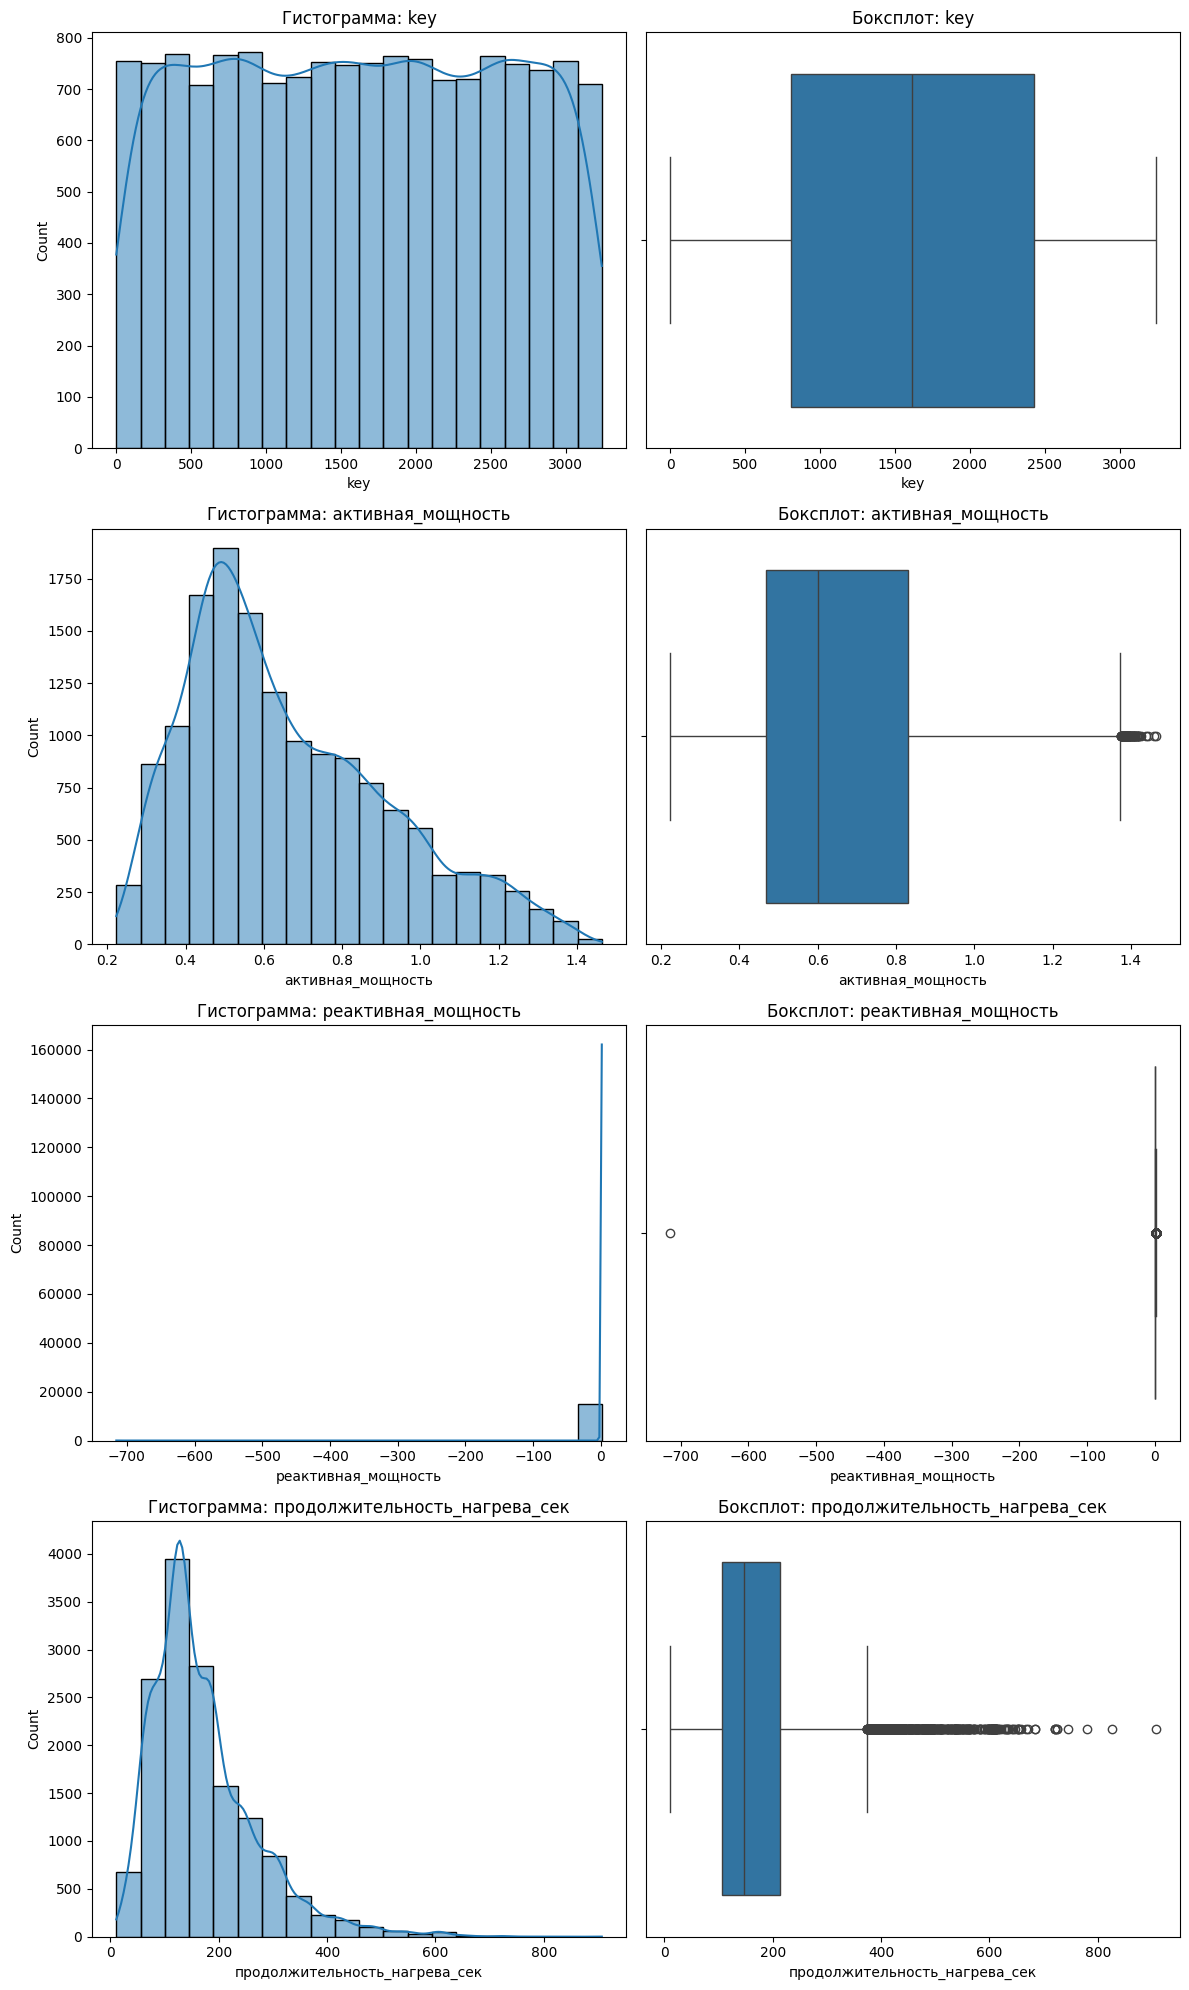

In [13]:
# теперь посмотрим распределение данных
plot_combined(df_arc, col=None, target=None, col_type=None, legend_loc='best')

Везде наблюдаем наличие сильных выбросов, проверим детальнее  
К тому же есть отрицательные значения чего не должно быть

In [14]:
df_arc[df_arc['активная_мощность'] > 1.3]

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность,продолжительность_нагрева_сек
171,38,2019-05-04 17:18:40,2019-05-04 17:21:07,1.336674,1.213404,147.0
296,64,2019-05-05 22:47:19,2019-05-05 22:49:19,1.316444,1.054070,120.0
331,70,2019-05-06 04:00:31,2019-05-06 04:02:06,1.341706,0.950409,95.0
493,106,2019-05-07 08:16:16,2019-05-07 08:21:28,1.327936,0.969106,312.0
517,113,2019-05-07 15:41:34,2019-05-07 15:43:52,1.317665,0.945464,138.0
...,...,...,...,...,...,...
14368,3123,2019-09-02 16:59:39,2019-09-02 17:00:40,1.330737,0.915607,61.0
14549,3166,2019-09-03 22:18:01,2019-09-03 22:20:04,1.368719,1.083031,123.0
14577,3172,2019-09-04 05:58:03,2019-09-04 06:03:15,1.316411,0.886694,312.0
14775,3219,2019-09-05 21:47:29,2019-09-05 21:51:18,1.347920,1.025508,229.0


Значения увеличиваются равномерно и постепенно, сложно сказать ошибка это или нет

In [15]:
df_arc[df_arc['реактивная_мощность'] < 0]

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность,продолжительность_нагрева_сек
9780,2116,2019-07-28 02:22:08,2019-07-28 02:23:57,0.705344,-715.479924,109.0


Явная ошибка заполнения данных, посчитаем среднюю активная_мощность и среднюю реактивная_мощность  
Посмотрим коэффицент изменения и изменим эту ошибку соответственно

In [16]:
avg_act_power = df_arc['активная_мощность'].mean()
avg_react_power = df_arc['реактивная_мощность'].mean()
koef_power = (avg_act_power / avg_react_power) - 1
logger.info(avg_act_power)
logger.info(avg_react_power)
logger.info(koef_power)


2026-03-05 10:50:16 [INFO] __main__: 0.6627522122882497
2026-03-05 10:50:16 [INFO] __main__: 0.43898642672761495
2026-03-05 10:50:16 [INFO] __main__: 0.5097328116239874


In [17]:
df_arc.loc[df_arc['реактивная_мощность'] < 0, 'реактивная_мощность'] = df_arc['активная_мощность'] * koef_power

In [18]:
df_arc[df_arc['продолжительность_нагрева_сек'] > 400]

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность,продолжительность_нагрева_сек
20,5,2019-05-03 13:23:32,2019-05-03 13:30:27,0.461620,0.308665,415.0
30,8,2019-05-03 14:53:56,2019-05-03 15:01:11,0.401980,0.292894,435.0
94,21,2019-05-04 03:42:26,2019-05-04 03:52:24,0.639156,0.425871,598.0
137,30,2019-05-04 10:49:25,2019-05-04 10:56:44,0.782927,0.546200,439.0
145,32,2019-05-04 12:58:33,2019-05-04 13:07:22,0.502953,0.352604,529.0
...,...,...,...,...,...,...
14654,3188,2019-09-04 20:54:34,2019-09-04 21:01:49,0.315474,0.254738,435.0
14659,3189,2019-09-04 22:29:02,2019-09-04 22:35:47,1.012875,0.772938,405.0
14772,3218,2019-09-05 20:49:26,2019-09-05 20:57:17,1.281652,1.074167,471.0
14779,3220,2019-09-05 22:35:56,2019-09-05 22:43:26,0.994169,0.720291,450.0


Здесь как будто бы тоже всё ок по времени, надо детальнее изучать вопрос относительно нормальности плавки

In [19]:
# добавим немного новых фич
df_arc['полная_мощность'] = np.sqrt(df_arc['активная_мощность']**2 + df_arc['реактивная_мощность']**2)
df_arc['соотношение_мощностей'] = df_arc['реактивная_мощность'] / df_arc['активная_мощность']
df_arc['энергия_нагрева'] = df_arc['активная_мощность'] * df_arc['продолжительность_нагрева_сек']
df_arc['cos_phi'] = 1 / np.sqrt(1 + df_arc['соотношение_мощностей']**2)

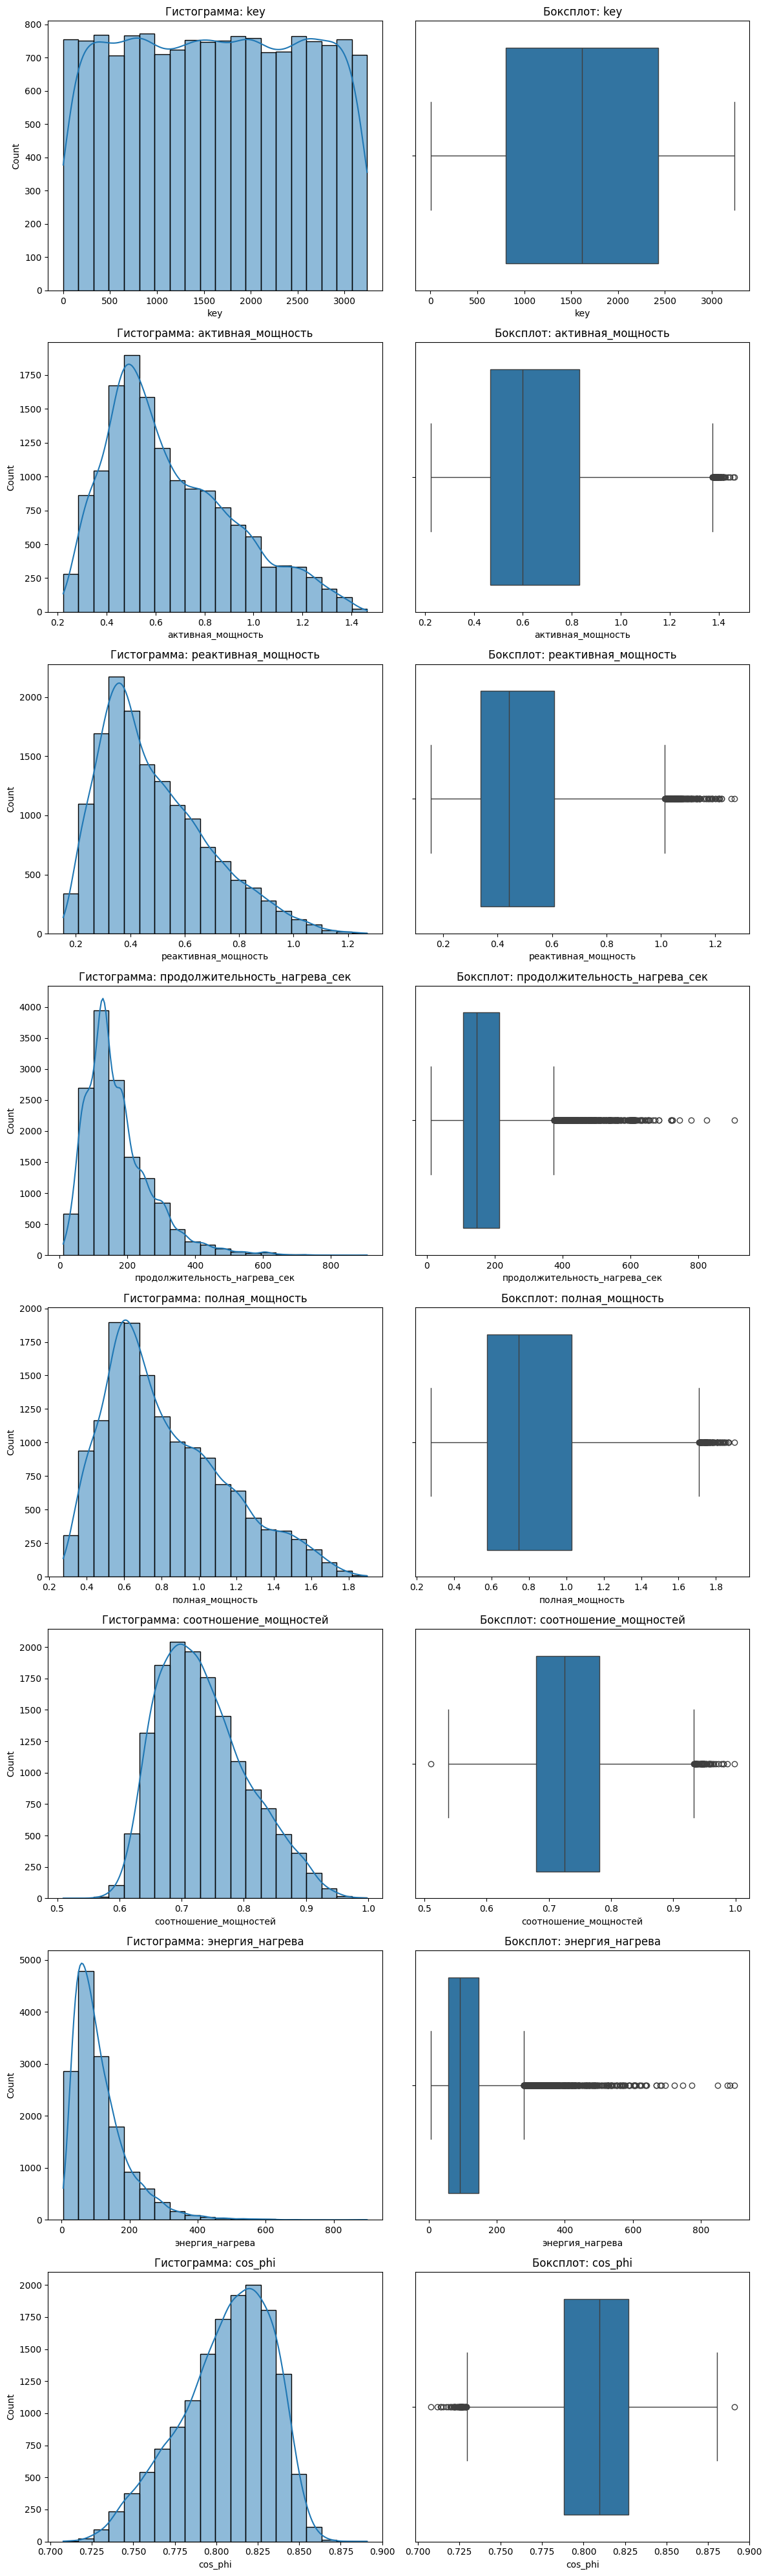

In [20]:
# теперь посмотрим распределение данных
plot_combined(df_arc, col=None, target=None, col_type=None, legend_loc='best')

In [21]:
display(df_arc.info())
display(df_arc.head())
display(df_arc.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   key                            14876 non-null  int64         
 1   начало_нагрева_дугой           14876 non-null  datetime64[ns]
 2   конец_нагрева_дугой            14876 non-null  datetime64[ns]
 3   активная_мощность              14876 non-null  float64       
 4   реактивная_мощность            14876 non-null  float64       
 5   продолжительность_нагрева_сек  14876 non-null  float64       
 6   полная_мощность                14876 non-null  float64       
 7   соотношение_мощностей          14876 non-null  float64       
 8   энергия_нагрева                14876 non-null  float64       
 9   cos_phi                        14876 non-null  float64       
dtypes: datetime64[ns](2), float64(7), int64(1)
memory usage: 1.1 MB


None

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность,продолжительность_нагрева_сек,полная_мощность,соотношение_мощностей,энергия_нагрева,cos_phi
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228.0,0.371123,0.692338,69.569640,0.822181
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,0.902319,0.623566,141.646730,0.848545
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460,172.0,0.722536,0.741772,99.813836,0.803161
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979,365.0,0.642824,0.732848,189.251040,0.806591
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691,148.0,1.079934,0.742321,128.335684,0.802950


,count,mean,min,25%,50%,75%,max,std
key,14876.0,1615.220422,1.0,806.0,1617.0,2429.0,3241.0,934.571502
начало_нагрева_дугой,14876,2019-07-05 12:25:51.921081088,2019-05-03 11:02:14,2019-06-03 23:18:23.249999872,2019-07-03 01:31:26.500000,2019-08-07 22:52:20.750000128,2019-09-06 17:24:54,NaN
конец_нагрева_дугой,14876,2019-07-05 12:28:43.592027392,2019-05-03 11:06:02,2019-06-03 23:21:35,2019-07-03 01:35:13,2019-08-07 22:56:47,2019-09-06 17:26:15,NaN
активная_мощность,14876.0,0.662752,0.22312,0.467115,0.599587,0.83007,1.463773,0.258885
реактивная_мощность,14876.0,0.487107,0.153777,0.337192,0.441639,0.608201,1.270284,0.197609
продолжительность_нагрева_сек,14876.0,171.670946,11.0,107.0,147.0,214.0,907.0,98.186803
полная_мощность,14876.0,0.823382,0.275718,0.578847,0.746591,1.03039,1.898158,0.323459
соотношение_мощностей,14876.0,0.734908,0.509733,0.679707,0.724754,0.781162,0.998261,0.072438
энергия_нагрева,14876.0,114.044276,5.246505,57.376903,92.194117,145.983547,898.200876,83.006059
cos_phi,14876.0,0.805893,0.707722,0.788058,0.809705,0.827039,0.890932,0.027664


И агрегируем данные по ключ  
Но только после того как создадим новые признаки

In [24]:
df_arc['число_нагревов'] = df_arc.groupby('key').cumcount() + 1

df_arc['длительность'] = (
    pd.to_datetime(df_arc['конец_нагрева_дугой']) - 
    pd.to_datetime(df_arc['начало_нагрева_дугой'])
).dt.total_seconds()

df_agg = df_arc.groupby('key').agg(
    количество_нагревов=('число_нагревов', 'count'),
    суммарная_длительность=('длительность', 'sum'),
    средняя_длительность=('длительность', 'mean'),
    максимальная_длительность=('длительность', 'max'),
    средняя_активная_мощность=('активная_мощность', 'mean'),
    максимальная_активная_мощность=('активная_мощность', 'max'),
    средняя_реактивная_мощность=('реактивная_мощность', 'mean'),
).reset_index()

df_arc = df_agg

In [25]:
# Одна плавка - одна строчка
display(df_arc.head())

,key,количество_нагревов,суммарная_длительность,средняя_длительность,максимальная_длительность,средняя_активная_мощность,максимальная_активная_мощность,средняя_реактивная_мощность
0,1,5,1098.0,219.60,365.0,0.607346,0.867133,0.428564
1,2,4,811.0,202.75,338.0,0.534852,0.786322,0.363339
2,3,5,655.0,131.00,280.0,0.812728,1.222963,0.587491
3,4,4,741.0,185.25,278.0,0.676622,0.887855,0.514248
4,5,4,869.0,217.25,415.0,0.563238,0.892957,0.421998


In [26]:
# и почистим от мусорных столбцов
df_arc = clear_df_missing_cols(df_arc)

2026-03-05 10:50:19 [INFO] __main__: Удалено признаков: 0
2026-03-05 10:50:19 [INFO] __main__: Осталось признаков: 8


In [27]:
# и сразу заменим на 0 пропуски в активной и реактивной мощностях

power_cols = [col for col in df_arc.columns 
              if 'активная_мощность' in col or 'реактивная_мощность' in col]

missing_before = df_arc[power_cols].isna().sum().sum()
# df_arc[power_cols] = df_arc[power_cols].fillna(0)

##### df_bulk

2026-03-05 10:50:19 [INFO] __main__: Общая информация базы данных


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   bulk_1   252 non-null    float64
 2   bulk_2   22 non-null     float64
 3   bulk_3   1298 non-null   float64
 4   bulk_4   1014 non-null   float64
 5   bulk_5   77 non-null     object 
 6   bulk_6   576 non-null    object 
 7   bulk_7   25 non-null     object 
 8   bulk_8   1 non-null      object 
 9   bulk_9   19 non-null     object 
 10  bulk_10  176 non-null    object 
 11  bulk_11  177 non-null    object 
 12  bulk_12  2450 non-null   object 
 13  bulk_13  18 non-null     object 
 14  bulk_14  2806 non-null   object 
 15  bulk_15  2248 non-null   object 
dtypes: float64(4), int64(1), object(11)
memory usage: 391.3+ KB


None

2026-03-05 10:50:19 [INFO] __main__: 5 случайных строк


,key,bulk_1,bulk_2,bulk_3,bulk_4,bulk_5,bulk_6,bulk_7,bulk_8,bulk_9,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15
2342,2427,NaN,NaN,44.0,NaN,None,66.0,None,None,None,None,None,None,None,89.0,None
141,155,NaN,NaN,NaN,NaN,None,None,None,None,None,None,None,106.0,None,100.0,203.0
74,86,NaN,NaN,NaN,NaN,None,36.0,None,None,None,None,107.0,307.0,None,152.0,204.0
679,712,NaN,NaN,NaN,NaN,None,None,None,None,None,None,None,205.0,None,101.0,None
225,242,NaN,NaN,91.0,NaN,None,None,None,None,None,None,None,None,None,254.0,None


2026-03-05 10:50:19 [INFO] __main__: Число пропусков в базе данных


bulk_1     2877
bulk_2     3107
bulk_3     1831
bulk_4     2115
bulk_5     3052
bulk_6     2553
bulk_7     3104
bulk_8     3128
bulk_9     3110
bulk_10    2953
bulk_11    2952
bulk_12     679
bulk_13    3111
bulk_14     323
bulk_15     881
dtype: int64

None

2026-03-05 10:50:19 [INFO] __main__: Визуализация пропусков


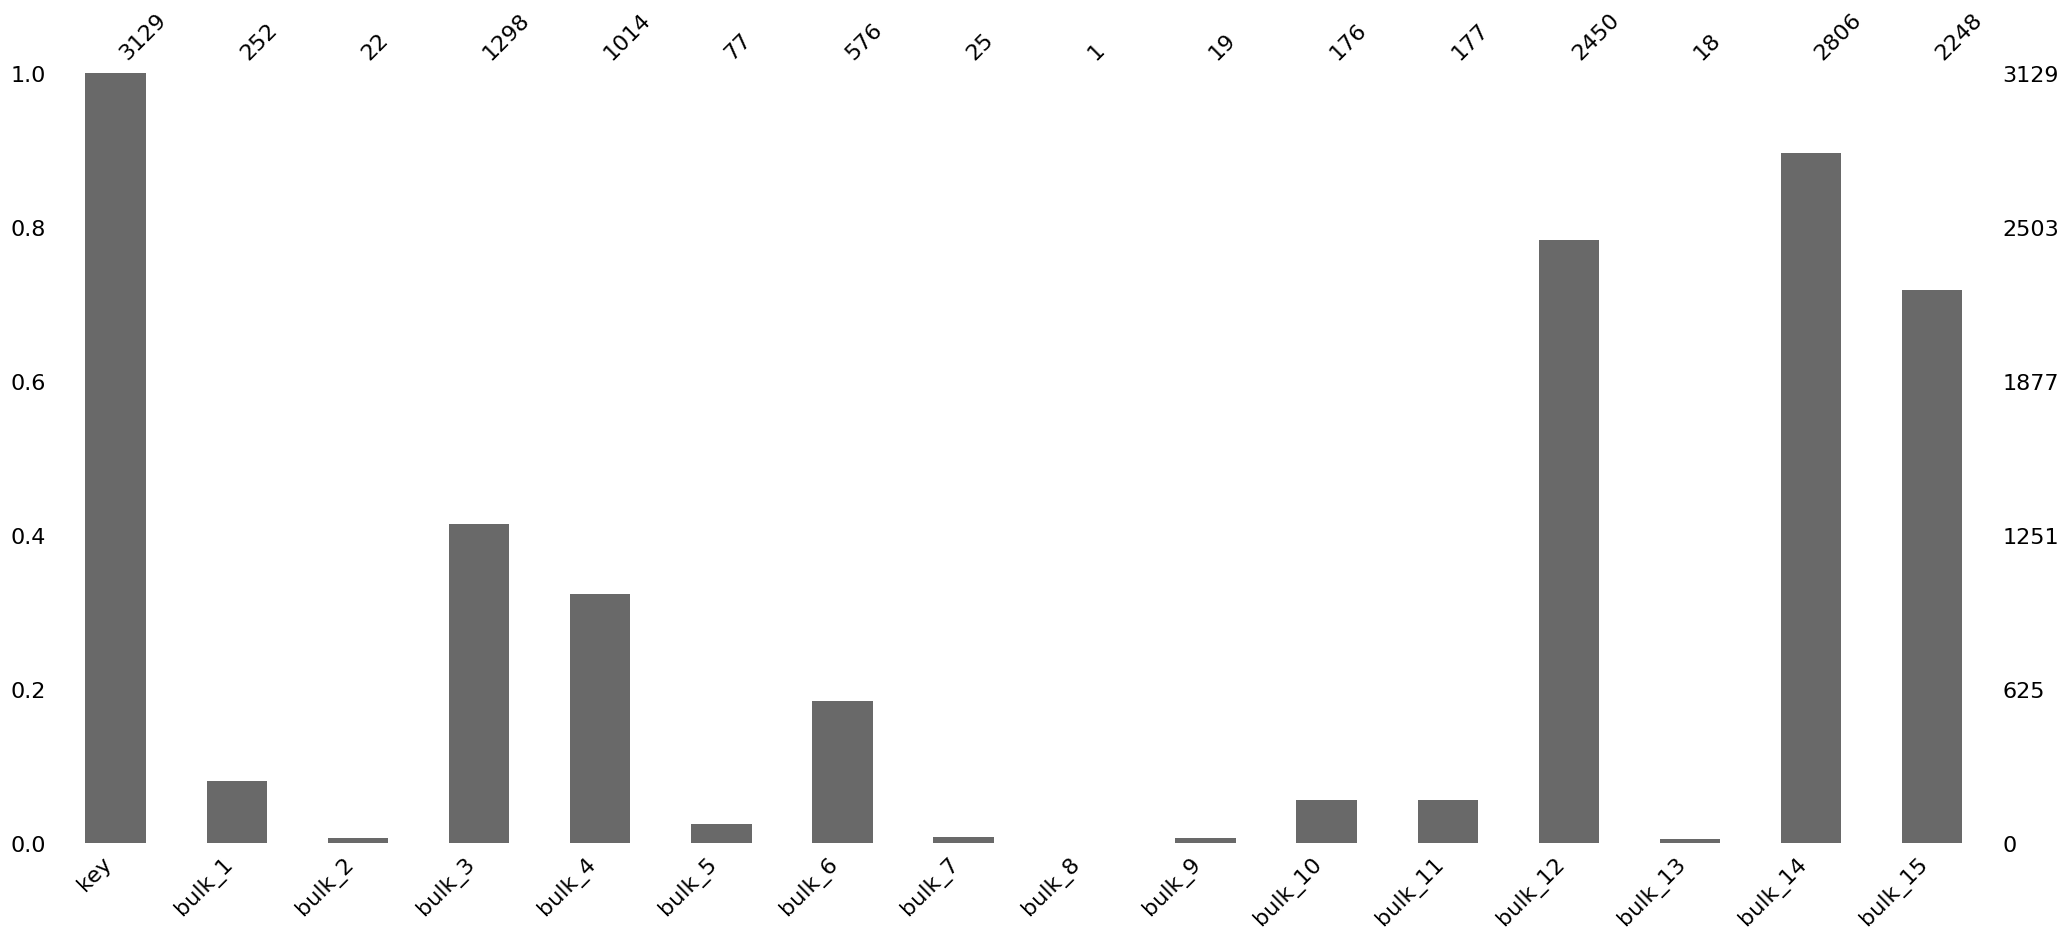

2026-03-05 10:50:19 [INFO] __main__: Характеристики базы данных


,count,mean,std,min,25%,50%,75%,max
key,3129.0,1624.383509,933.337642,1.0,816.0,1622.0,2431.00,3241.0
bulk_1,252.0,39.242063,18.277654,10.0,27.0,31.0,46.00,185.0
bulk_2,22.0,253.045455,21.180578,228.0,242.0,251.5,257.75,325.0
bulk_3,1298.0,113.879045,75.483494,6.0,58.0,97.5,152.00,454.0
bulk_4,1014.0,104.394477,48.184126,12.0,72.0,102.0,133.00,281.0


In [28]:
df_bulk = check_data(df_bulk)

Много пропусков - но это мелочи.  
Заменим на 0, т.к. это просто означает, что не было подачи сыпучего материала.  
Ну и тип данных везде поменять на float  

PS: после первых экспериментов попробуем убрать те загрузки, где больше 50% - пропуски

In [29]:
df_bulk = clear_df_missing_cols(df_bulk)

2026-03-05 10:50:19 [INFO] __main__: Удалено признаков: 12
2026-03-05 10:50:19 [INFO] __main__: Осталось признаков: 4


In [30]:
for col in df_bulk.columns:
    if col != 'key':
        df_bulk[col] = df_bulk[col].astype(float)

In [31]:
df_bulk.describe().T

,count,mean,std,min,25%,50%,75%,max
key,3129.0,1624.383509,933.337642,1.0,816.0,1622.0,2431.00,3241.0
bulk_12,2450.0,260.471020,120.649269,53.0,204.0,208.0,316.00,1849.0
bulk_14,2806.0,170.284747,65.868652,16.0,119.0,151.0,205.75,636.0
bulk_15,2248.0,160.513345,51.765319,1.0,105.0,160.0,205.00,405.0


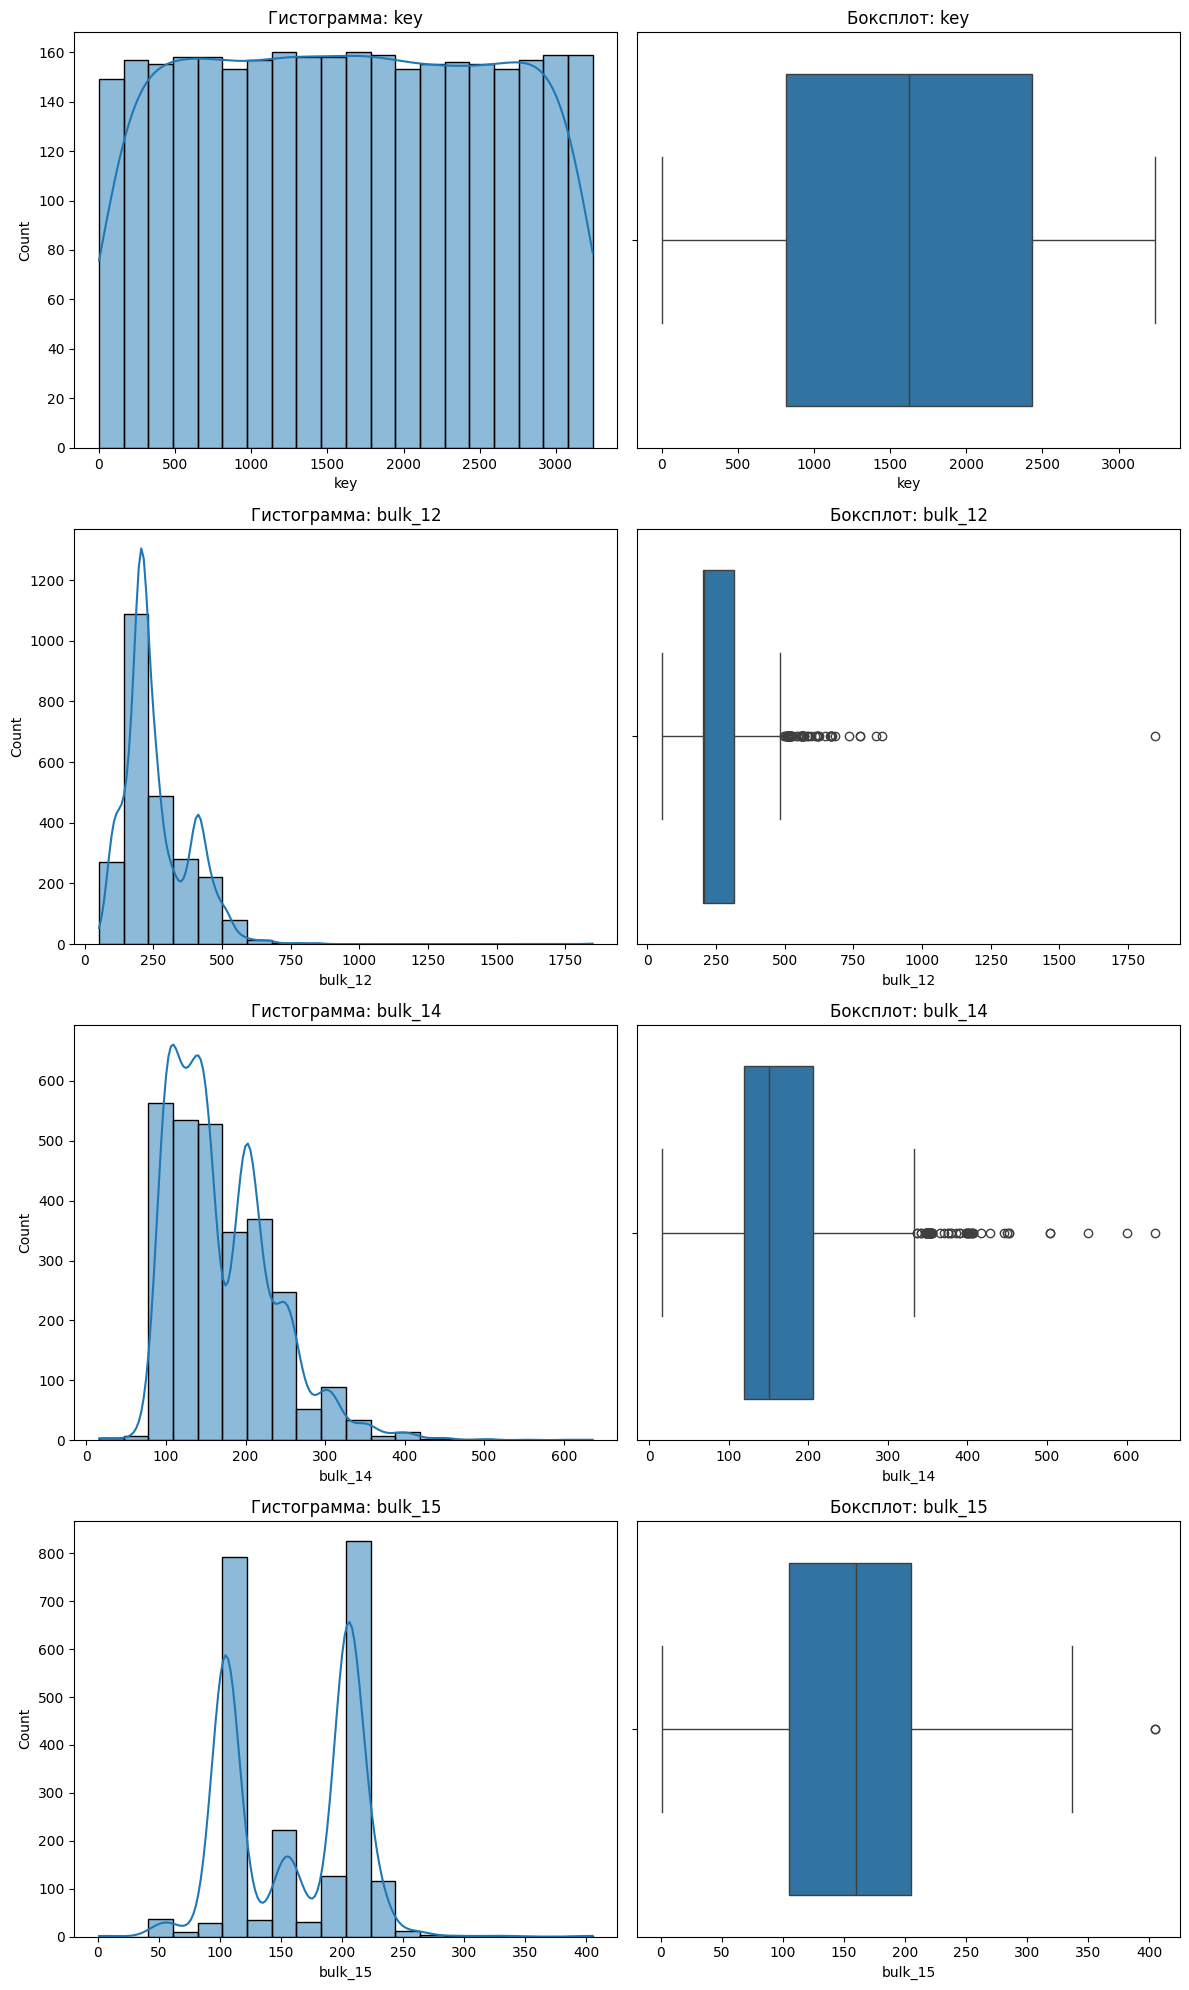

In [32]:
# теперь посмотрим распределение данных
plot_combined(df_bulk, col=None, target=None, col_type=None, legend_loc='best')

Все добавки выше нуля - это главное  
а по числу добавок - сложно понять, что мы добавляем и сколько этого надо...

In [33]:
display(df_bulk.info())
display(df_bulk.head())
display(df_bulk.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   bulk_12  2450 non-null   float64
 2   bulk_14  2806 non-null   float64
 3   bulk_15  2248 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 97.9 KB


None

,key,bulk_12,bulk_14,bulk_15
0,1,206.0,150.0,154.0
1,2,206.0,149.0,154.0
2,3,205.0,152.0,153.0
3,4,207.0,153.0,154.0
4,5,203.0,151.0,152.0


,count,mean,std,min,25%,50%,75%,max
key,3129.0,1624.383509,933.337642,1.0,816.0,1622.0,2431.00,3241.0
bulk_12,2450.0,260.471020,120.649269,53.0,204.0,208.0,316.00,1849.0
bulk_14,2806.0,170.284747,65.868652,16.0,119.0,151.0,205.75,636.0
bulk_15,2248.0,160.513345,51.765319,1.0,105.0,160.0,205.00,405.0


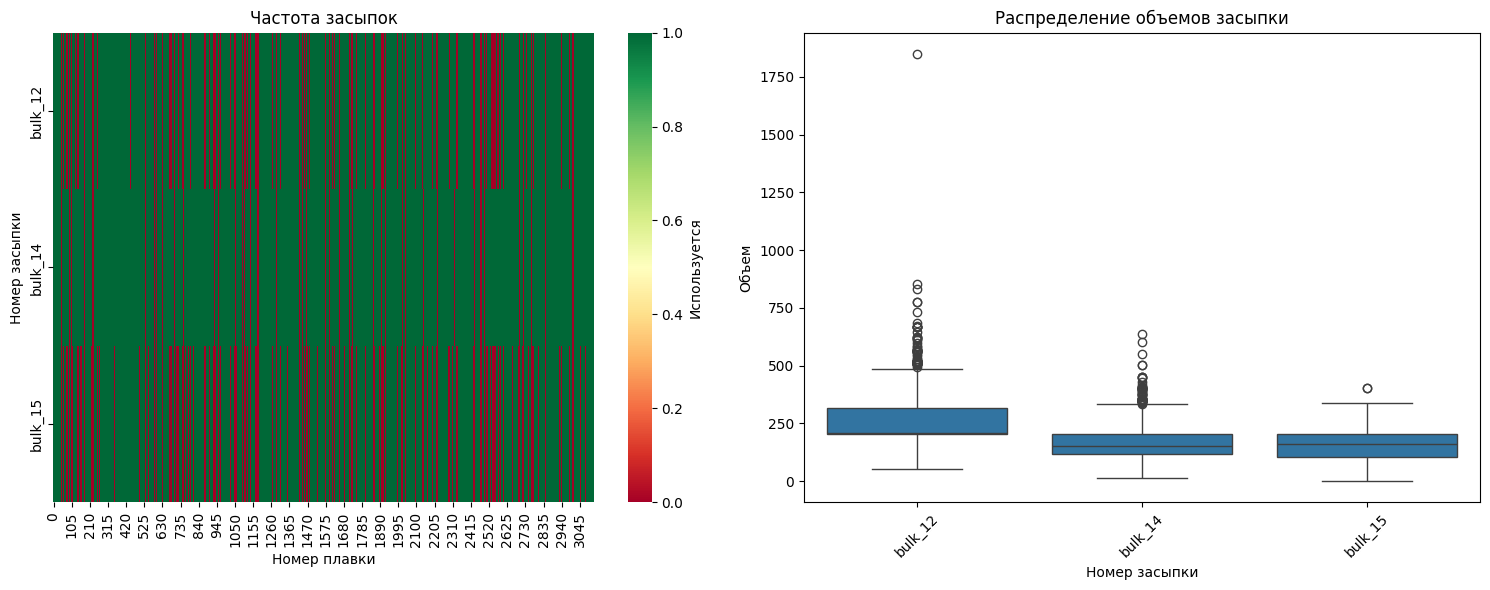

In [34]:
bulk_cols = [col for col in df_bulk.columns if col.startswith('bulk_')]
bulk_cols = sorted(bulk_cols, key=lambda x: int(x.split('_')[1]))

if len(bulk_cols) == 0:
    logger.warning("Нет колонок bulk_ для построения графиков. Пропускаем визуализацию.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Тепловая карта засыпок
    usage_matrix = pd.DataFrame({col: (df_bulk[col] > 0).astype(int) for col in bulk_cols})
    sns.heatmap(usage_matrix.T, cmap='RdYlGn', cbar_kws={'label': 'Используется'}, ax=axes[0])
    axes[0].set_title('Частота засыпок')
    axes[0].set_xlabel('Номер плавки')
    axes[0].set_ylabel('Номер засыпки')

    # Распределение объемов
    data_for_box = df_bulk[bulk_cols].melt(var_name='Номер засыпки', value_name='Объем')
    data_for_box = data_for_box[data_for_box['Объем'] > 0]
    if data_for_box.empty:
        logger.warning("Нет ненулевых объемов для boxplot.")
    else:
        sns.boxplot(data=data_for_box, x='Номер засыпки', y='Объем', ax=axes[1])
        axes[1].set_title('Распределение объемов засыпки')
        axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

Посмотрим отдельно на выброс засыпки в номере 12  
Именно номер плавки по порядку, непонятно

In [35]:
df_bulk.head()

,key,bulk_12,bulk_14,bulk_15
0,1,206.0,150.0,154.0
1,2,206.0,149.0,154.0
2,3,205.0,152.0,153.0
3,4,207.0,153.0,154.0
4,5,203.0,151.0,152.0


In [36]:
display(df_bulk[df_bulk['bulk_12'] > 600])

,key,bulk_12,bulk_14,bulk_15
11,12,618.0,406.0,203.0
207,223,666.0,316.0,202.0
303,322,1849.0,636.0,NaN
308,327,775.0,403.0,205.0
418,444,671.0,379.0,203.0
841,877,669.0,102.0,NaN
960,1005,668.0,198.0,205.0
1005,1050,647.0,371.0,103.0
1175,1224,668.0,213.0,NaN
1240,1290,609.0,275.0,158.0


Непонятно все равно, может быть и есть в этом какая-то логика, но мне она отсюда не видна.  
Лучше сделаем новые фичи:  
1) Суммарный объем засыпок;  
2) Число засыпок;  

In [37]:
bulk_cols = [col for col in df_bulk.columns if 'bulk_' in col.lower()]
df_bulk['total_bulk'] = df_bulk[bulk_cols].sum(axis=1)

In [38]:
df_bulk['count_bulk'] = df_bulk[bulk_cols].count(axis=1)

In [39]:
df_bulk.head()

,key,bulk_12,bulk_14,bulk_15,total_bulk,count_bulk
0,1,206.0,150.0,154.0,510.0,3
1,2,206.0,149.0,154.0,509.0,3
2,3,205.0,152.0,153.0,510.0,3
3,4,207.0,153.0,154.0,514.0,3
4,5,203.0,151.0,152.0,506.0,3


2026-03-05 10:50:21 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-05 10:50:21 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


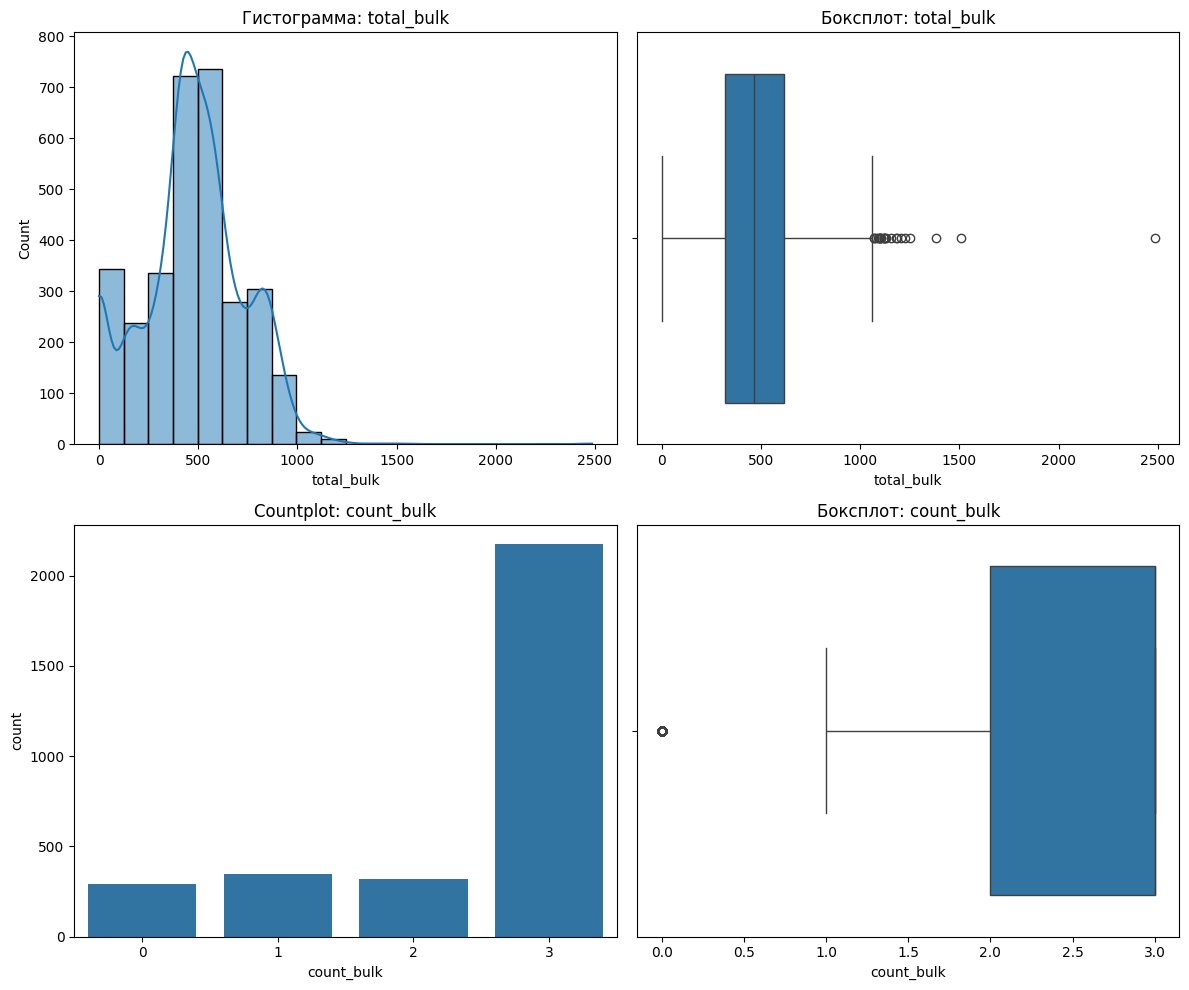

In [40]:
# и посмотрим что вышло
cols = ['total_bulk', 'count_bulk']
plot_combined(df_bulk, col=cols, target=None, col_type=None, legend_loc='best')

In [41]:
# df_bulk = df_bulk.fillna(0)

##### df_bulk_time

2026-03-05 10:50:21 [INFO] __main__: Общая информация базы данных


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   key      3129 non-null   int64 
 1   bulk_1   252 non-null    object
 2   bulk_2   22 non-null     object
 3   bulk_3   1298 non-null   object
 4   bulk_4   1014 non-null   object
 5   bulk_5   77 non-null     object
 6   bulk_6   576 non-null    object
 7   bulk_7   25 non-null     object
 8   bulk_8   1 non-null      object
 9   bulk_9   19 non-null     object
 10  bulk_10  176 non-null    object
 11  bulk_11  177 non-null    object
 12  bulk_12  2450 non-null   object
 13  bulk_13  18 non-null     object
 14  bulk_14  2806 non-null   object
 15  bulk_15  2248 non-null   object
dtypes: int64(1), object(15)
memory usage: 391.3+ KB


None

2026-03-05 10:50:21 [INFO] __main__: 5 случайных строк


,key,bulk_1,bulk_2,bulk_3,bulk_4,bulk_5,bulk_6,bulk_7,bulk_8,bulk_9,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15
2898,3004,None,None,2019-08-29 12:53:14,None,None,None,None,None,None,None,None,2019-08-29 12:50:30,None,2019-08-29 12:53:14,2019-08-29 12:50:30
1853,1916,None,None,2019-07-19 05:35:52,None,None,None,None,None,None,None,None,None,None,2019-07-19 05:28:52,None
1420,1474,None,None,None,2019-06-28 00:30:14,None,None,None,None,None,2019-06-28 00:30:14,None,2019-06-28 00:25:35,None,2019-06-28 00:19:53,2019-06-28 00:14:15
2173,2252,None,None,None,2019-08-01 14:30:05,None,None,None,None,None,None,None,2019-08-01 14:39:19,None,2019-08-01 14:34:51,2019-08-01 14:30:05
2520,2616,None,None,None,None,None,None,None,None,None,2019-08-14 23:20:47,None,2019-08-14 23:36:46,None,2019-08-14 23:32:54,2019-08-14 23:26:10


2026-03-05 10:50:21 [INFO] __main__: Число пропусков в базе данных


bulk_1     2877
bulk_2     3107
bulk_3     1831
bulk_4     2115
bulk_5     3052
bulk_6     2553
bulk_7     3104
bulk_8     3128
bulk_9     3110
bulk_10    2953
bulk_11    2952
bulk_12     679
bulk_13    3111
bulk_14     323
bulk_15     881
dtype: int64

None

2026-03-05 10:50:21 [INFO] __main__: Визуализация пропусков


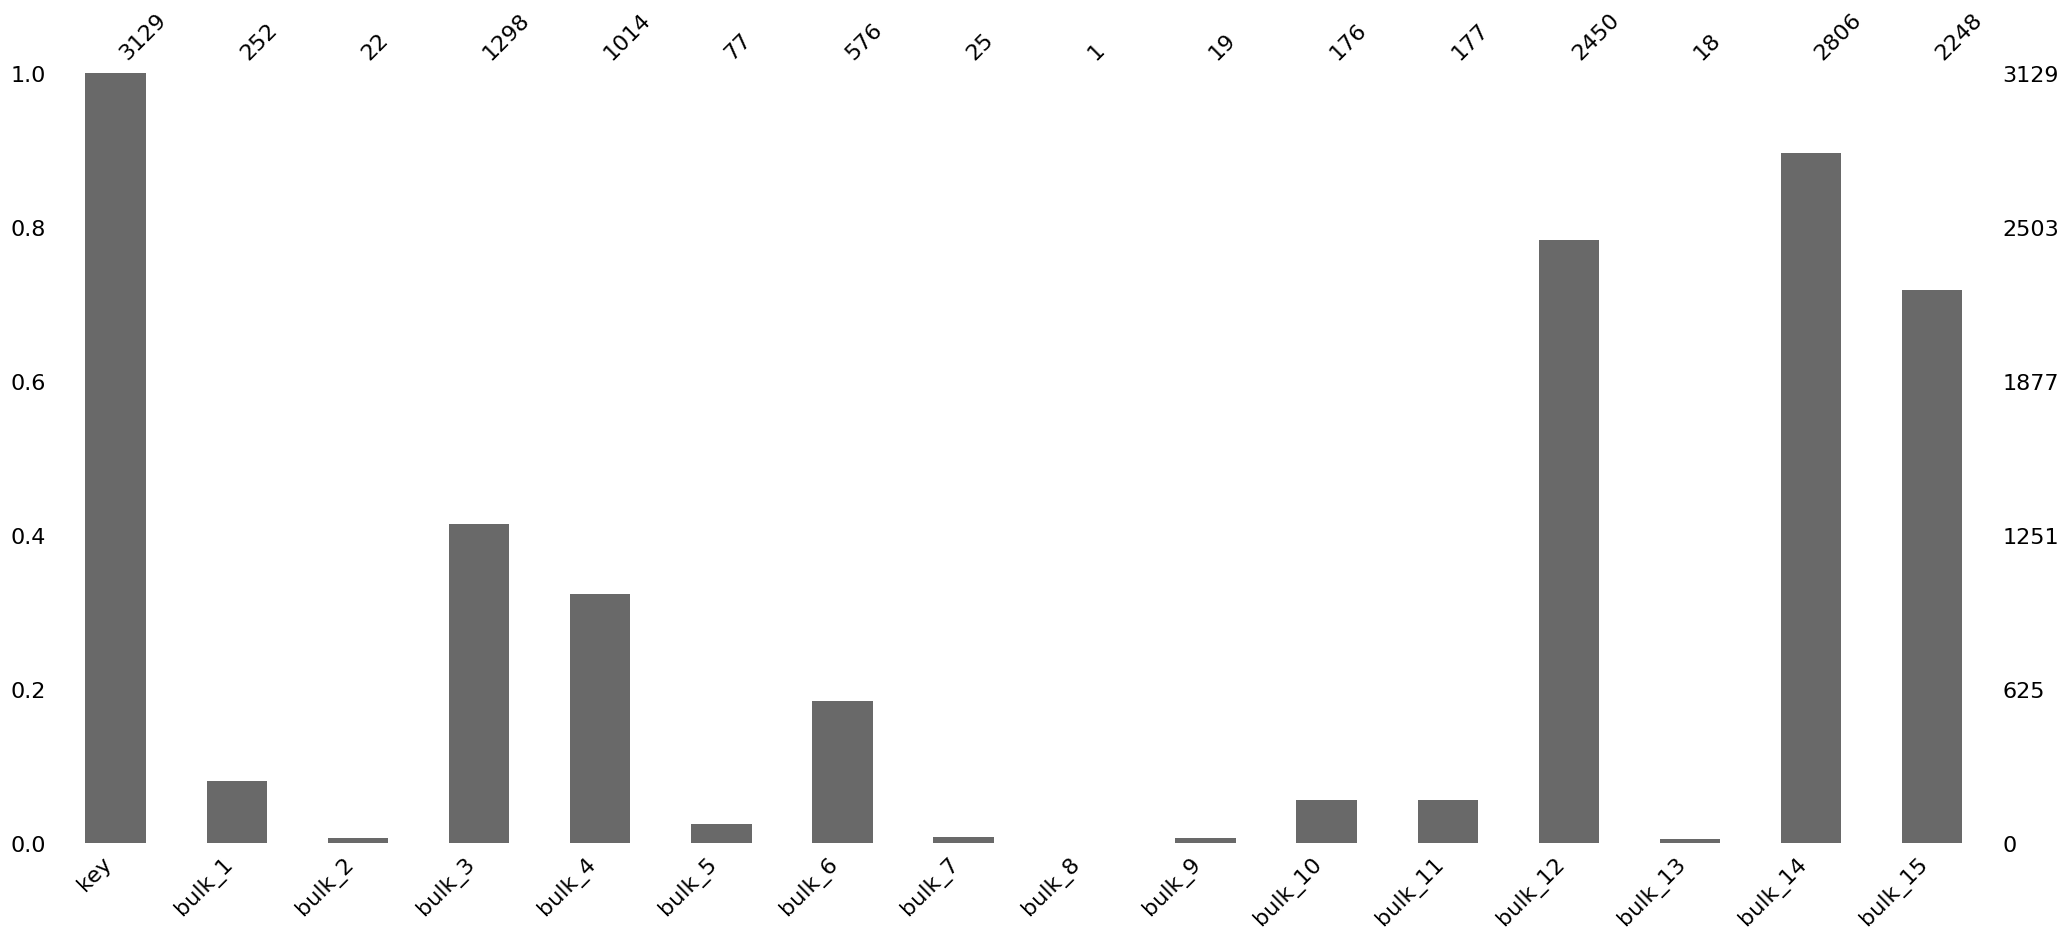

2026-03-05 10:50:21 [INFO] __main__: Характеристики базы данных


,count,mean,std,min,25%,50%,75%,max
key,3129.0,1624.383509,933.337642,1.0,816.0,1622.0,2431.0,3241.0


In [42]:
df_bulk_time = check_data(df_bulk_time)

Аналогично и тут пропуски - время подачи, т.к. не было подачи по факту то и не было фиксации времени  
Здесь видимо пропуски будут NaT

In [43]:
df_bulk_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   key      3129 non-null   int64 
 1   bulk_1   252 non-null    object
 2   bulk_2   22 non-null     object
 3   bulk_3   1298 non-null   object
 4   bulk_4   1014 non-null   object
 5   bulk_5   77 non-null     object
 6   bulk_6   576 non-null    object
 7   bulk_7   25 non-null     object
 8   bulk_8   1 non-null      object
 9   bulk_9   19 non-null     object
 10  bulk_10  176 non-null    object
 11  bulk_11  177 non-null    object
 12  bulk_12  2450 non-null   object
 13  bulk_13  18 non-null     object
 14  bulk_14  2806 non-null   object
 15  bulk_15  2248 non-null   object
dtypes: int64(1), object(15)
memory usage: 391.3+ KB


In [44]:
df_bulk_time.head()

,key,bulk_1,bulk_2,bulk_3,bulk_4,bulk_5,bulk_6,bulk_7,bulk_8,bulk_9,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15
0,1,None,None,None,2019-05-03 11:28:48,None,None,None,None,None,None,None,2019-05-03 11:24:31,None,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2,None,None,None,2019-05-03 11:36:50,None,None,None,None,None,None,None,2019-05-03 11:53:30,None,2019-05-03 11:48:37,2019-05-03 11:44:39
2,3,None,None,None,2019-05-03 12:32:39,None,None,None,None,None,None,None,2019-05-03 12:27:13,None,2019-05-03 12:21:01,2019-05-03 12:16:16
3,4,None,None,None,2019-05-03 12:43:22,None,None,None,None,None,None,None,2019-05-03 12:58:00,None,2019-05-03 12:51:11,2019-05-03 12:46:36
4,5,None,None,None,2019-05-03 13:30:47,None,None,None,None,None,None,None,2019-05-03 13:30:47,None,2019-05-03 13:34:12,2019-05-03 13:30:47


Интересное наблюдение, отсчет идет с последней засыпке к 1й...   
Ну да пусть, нам бы посчитать суммарное время  

In [45]:
df_bulk_time = clear_df_missing_cols(df_bulk_time)

2026-03-05 10:50:22 [INFO] __main__: Удалено признаков: 12
2026-03-05 10:50:22 [INFO] __main__: Осталось признаков: 4


In [46]:
df_bulk_time

,key,bulk_12,bulk_14,bulk_15
0,1,2019-05-03 11:24:31,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2,2019-05-03 11:53:30,2019-05-03 11:48:37,2019-05-03 11:44:39
2,3,2019-05-03 12:27:13,2019-05-03 12:21:01,2019-05-03 12:16:16
3,4,2019-05-03 12:58:00,2019-05-03 12:51:11,2019-05-03 12:46:36
4,5,2019-05-03 13:30:47,2019-05-03 13:34:12,2019-05-03 13:30:47
...,...,...,...,...
3124,3237,2019-09-06 11:49:45,2019-09-06 11:45:22,2019-09-06 11:40:06
3125,3238,2019-09-06 12:18:35,2019-09-06 12:31:49,2019-09-06 12:26:52
3126,3239,2019-09-06 15:01:44,2019-09-06 14:58:15,2019-09-06 14:48:06
3127,3240,None,2019-09-06 16:07:29,2019-09-06 16:01:34


In [47]:
bulk_time_cols = [col for col in df_bulk_time.columns if 'bulk_' in col.lower()]
df_bulk_time[bulk_time_cols] = df_bulk_time[bulk_time_cols].astype('datetime64[ns]')

In [48]:
df_bulk_time['начало_засыпок'] = df_bulk_time[bulk_time_cols].min(axis=1)
df_bulk_time['конец_засыпок'] = df_bulk_time[bulk_time_cols].max(axis=1)
df_bulk_time['общее_время_засыпок'] = (df_bulk_time['конец_засыпок'] - df_bulk_time['начало_засыпок']).dt.total_seconds()

In [49]:
# ну и средний интервал между подачами заодно

df_bulk_time['интервал_подачи_avg'] = (
    df_bulk_time[bulk_time_cols]
    .apply(lambda row: row.dropna().sort_values().diff().dt.total_seconds().mean(), axis=1)
)

In [50]:
display(df_bulk_time.head())
display(df_bulk_time.info())
display(df_bulk_time.describe().T)

,key,bulk_12,bulk_14,bulk_15,начало_засыпок,конец_засыпок,общее_время_засыпок,интервал_подачи_avg
0,1,2019-05-03 11:24:31,2019-05-03 11:14:50,2019-05-03 11:10:43,2019-05-03 11:10:43,2019-05-03 11:24:31,828.0,414.0
1,2,2019-05-03 11:53:30,2019-05-03 11:48:37,2019-05-03 11:44:39,2019-05-03 11:44:39,2019-05-03 11:53:30,531.0,265.5
2,3,2019-05-03 12:27:13,2019-05-03 12:21:01,2019-05-03 12:16:16,2019-05-03 12:16:16,2019-05-03 12:27:13,657.0,328.5
3,4,2019-05-03 12:58:00,2019-05-03 12:51:11,2019-05-03 12:46:36,2019-05-03 12:46:36,2019-05-03 12:58:00,684.0,342.0
4,5,2019-05-03 13:30:47,2019-05-03 13:34:12,2019-05-03 13:30:47,2019-05-03 13:30:47,2019-05-03 13:34:12,205.0,102.5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   key                  3129 non-null   int64         
 1   bulk_12              2450 non-null   datetime64[ns]
 2   bulk_14              2806 non-null   datetime64[ns]
 3   bulk_15              2248 non-null   datetime64[ns]
 4   начало_засыпок       2840 non-null   datetime64[ns]
 5   конец_засыпок        2840 non-null   datetime64[ns]
 6   общее_время_засыпок  2840 non-null   float64       
 7   интервал_подачи_avg  2491 non-null   float64       
dtypes: datetime64[ns](5), float64(2), int64(1)
memory usage: 195.7 KB


None

,count,mean,min,25%,50%,75%,max,std
key,3129.0,1624.383509,1.0,816.0,1622.0,2431.0,3241.0,933.337642
bulk_12,2450,2019-07-05 22:55:11.468571392,2019-05-03 11:24:31,2019-06-03 12:48:47.249999872,2019-07-03 01:32:00,2019-08-08 14:55:05.249999872,2019-09-06 15:01:44,NaN
bulk_14,2806,2019-07-06 07:17:48.372772608,2019-05-03 11:14:50,2019-06-04 04:50:42,2019-07-03 21:54:13.500000,2019-08-09 04:22:40.500000,2019-09-06 17:26:33,NaN
bulk_15,2248,2019-07-06 13:24:51.912366336,2019-05-03 11:10:43,2019-06-04 11:28:18,2019-07-03 16:43:28.500000,2019-08-09 09:18:31.750000128,2019-09-06 17:23:15,NaN
начало_засыпок,2840,2019-07-06 07:58:04.718661888,2019-05-03 11:10:43,2019-06-04 08:58:25.750000128,2019-07-03 21:48:56.500000,2019-08-09 01:48:19.750000128,2019-09-06 17:23:15,NaN
конец_засыпок,2840,2019-07-06 08:10:06.822183168,2019-05-03 11:24:31,2019-06-04 09:07:02.500000,2019-07-03 22:04:46,2019-08-09 01:51:16.500000,2019-09-06 17:26:33,NaN
общее_время_засыпок,2840.0,722.103521,0.0,379.0,659.0,958.25,12946.0,605.945058
интервал_подачи_avg,2491.0,438.533521,0.0,289.5,375.0,535.75,6473.0,293.878928


Вылезла неадекватная продолжительность подачи, посмотрим поближе

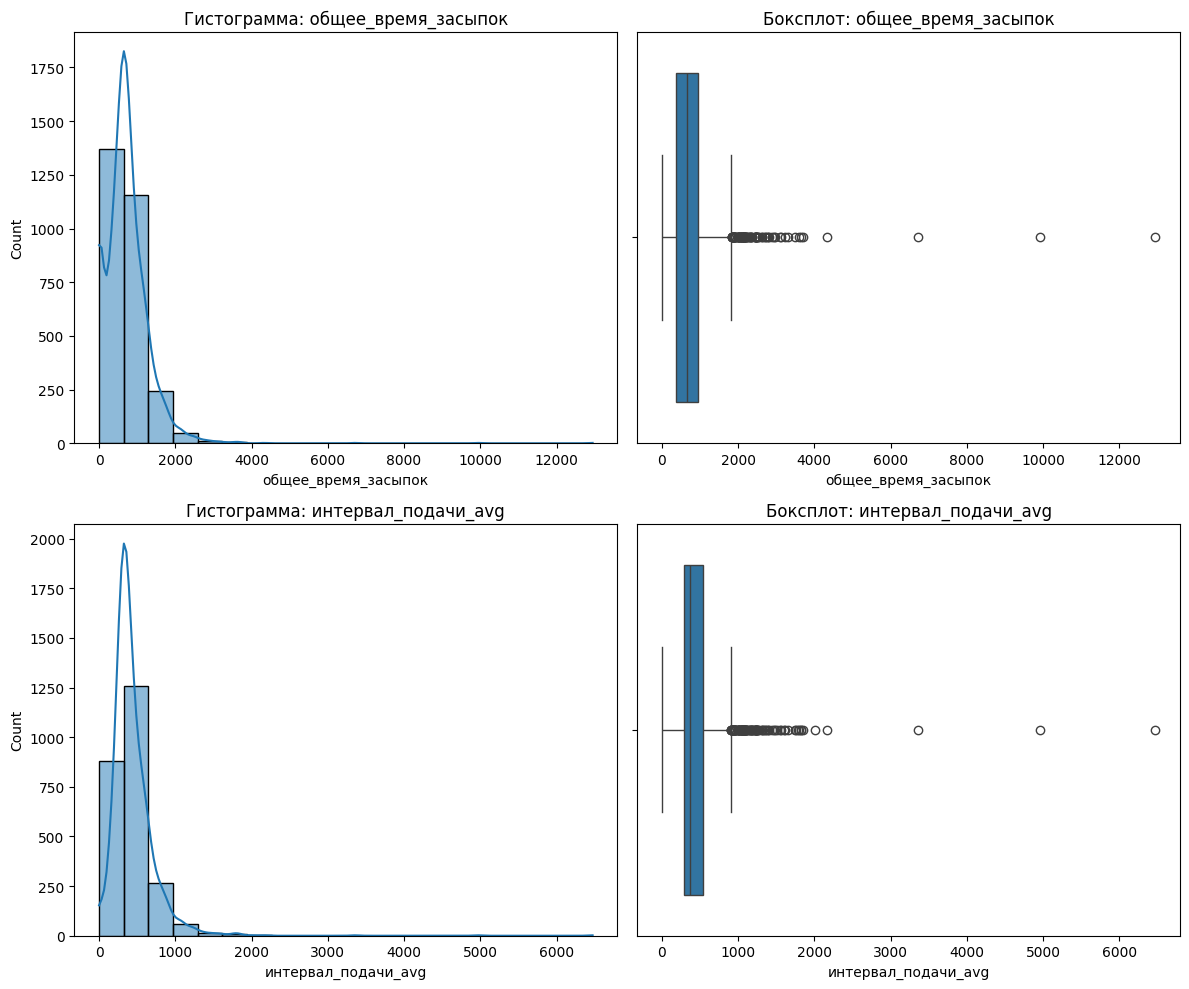

In [51]:
# и посмотрим что вышло
cols = ['общее_время_засыпок', 'интервал_подачи_avg']
plot_combined(df_bulk_time, col=cols, target=None, col_type=None, legend_loc='best')

##### df_gas

In [52]:
df_gas = check_data(df_gas)

2026-03-05 10:50:23 [INFO] __main__: Общая информация базы данных


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3239 non-null   int64  
 1   газ_1   3239 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 50.7 KB


None

2026-03-05 10:50:23 [INFO] __main__: 5 случайных строк


,key,газ_1
496,499,13.837547
3211,3214,2.238245
2027,2030,7.281293
389,392,6.979520
58,59,1.279322


2026-03-05 10:50:23 [INFO] __main__: Число пропусков в базе данных


Series([], dtype: int64)

None

2026-03-05 10:50:23 [INFO] __main__: Характеристики базы данных


,count,mean,std,min,25%,50%,75%,max
key,3239.0,1621.861377,935.386334,1.000000,812.500000,1622.000000,2431.500000,3241.00000
газ_1,3239.0,11.002062,6.220327,0.008399,7.043089,9.836267,13.769915,77.99504


Тут на первый взгляд все у нас хорошо  
но посмотрим и на график

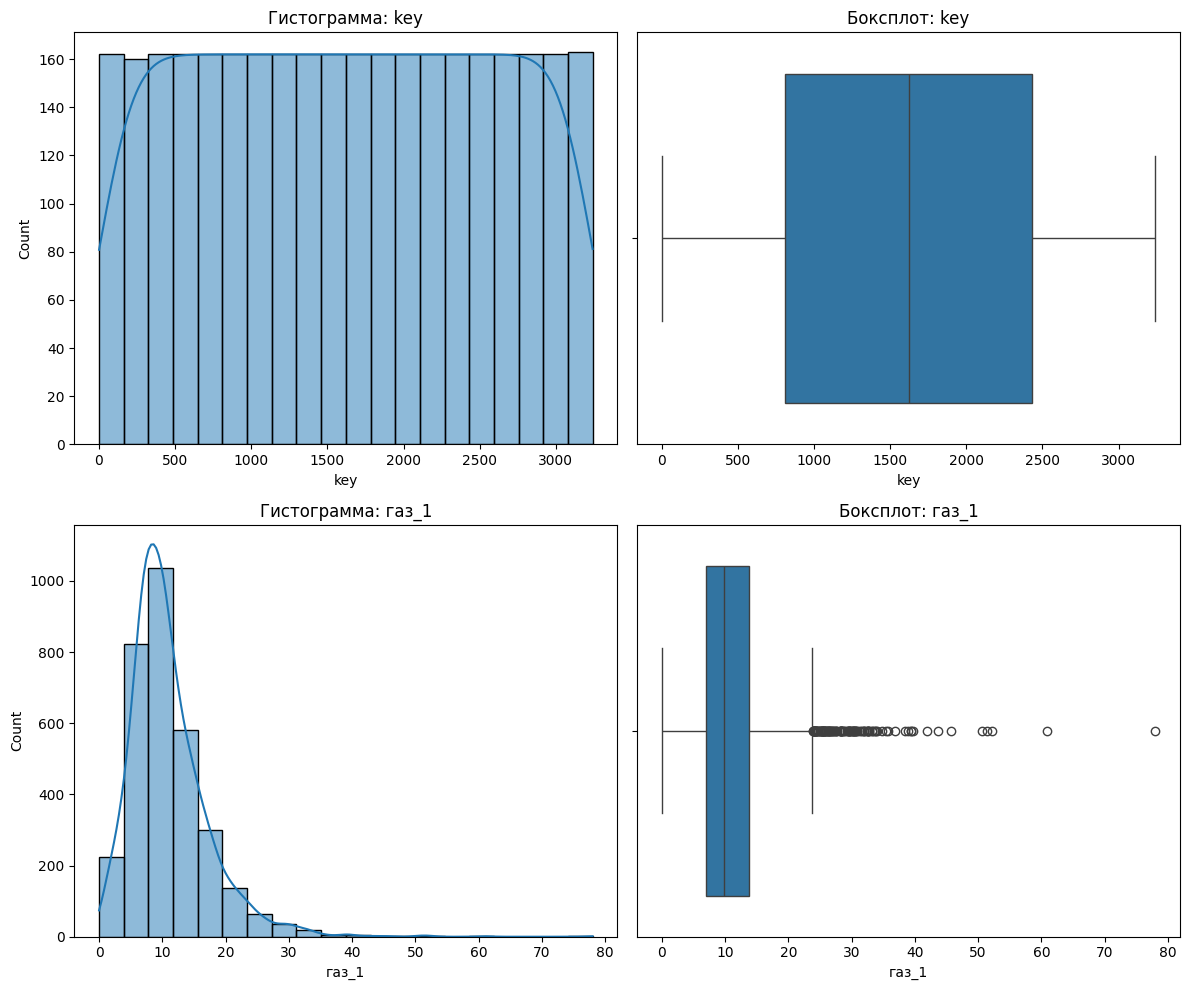

In [53]:
plot_combined(df_gas, col=None, target=None, col_type=None, legend_loc='best')

Не такой больше различие у максимума, но все равно посмотрим на бОльшие значения

In [54]:
display(df_gas[df_gas['газ_1'] > 50])

,key,газ_1
116,117,50.581035
277,280,60.935689
319,322,77.995040
2107,2110,52.142373
2567,2570,51.380229


Ну дали чутка больше газа и ладно, бывает

##### df_temp

2026-03-05 10:50:24 [INFO] __main__: Общая информация базы данных


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18092 entries, 0 to 18091
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   key           18092 non-null  int64 
 1   время_замера  18092 non-null  object
 2   температура   14665 non-null  object
dtypes: int64(1), object(2)
memory usage: 424.2+ KB


None

2026-03-05 10:50:24 [INFO] __main__: 5 случайных строк


,key,время_замера,температура
12630,2259,2019-08-01 18:36:25,1575.0
14892,2660,2019-08-16 18:21:00,None
10117,1811,2019-07-09 17:57:26,1585.0
15447,2761,2019-08-20 08:03:45,None
6174,1101,2019-06-14 15:22:50,1596.0


2026-03-05 10:50:24 [INFO] __main__: Число пропусков в базе данных


температура    3427
dtype: int64

None

2026-03-05 10:50:24 [INFO] __main__: Визуализация пропусков


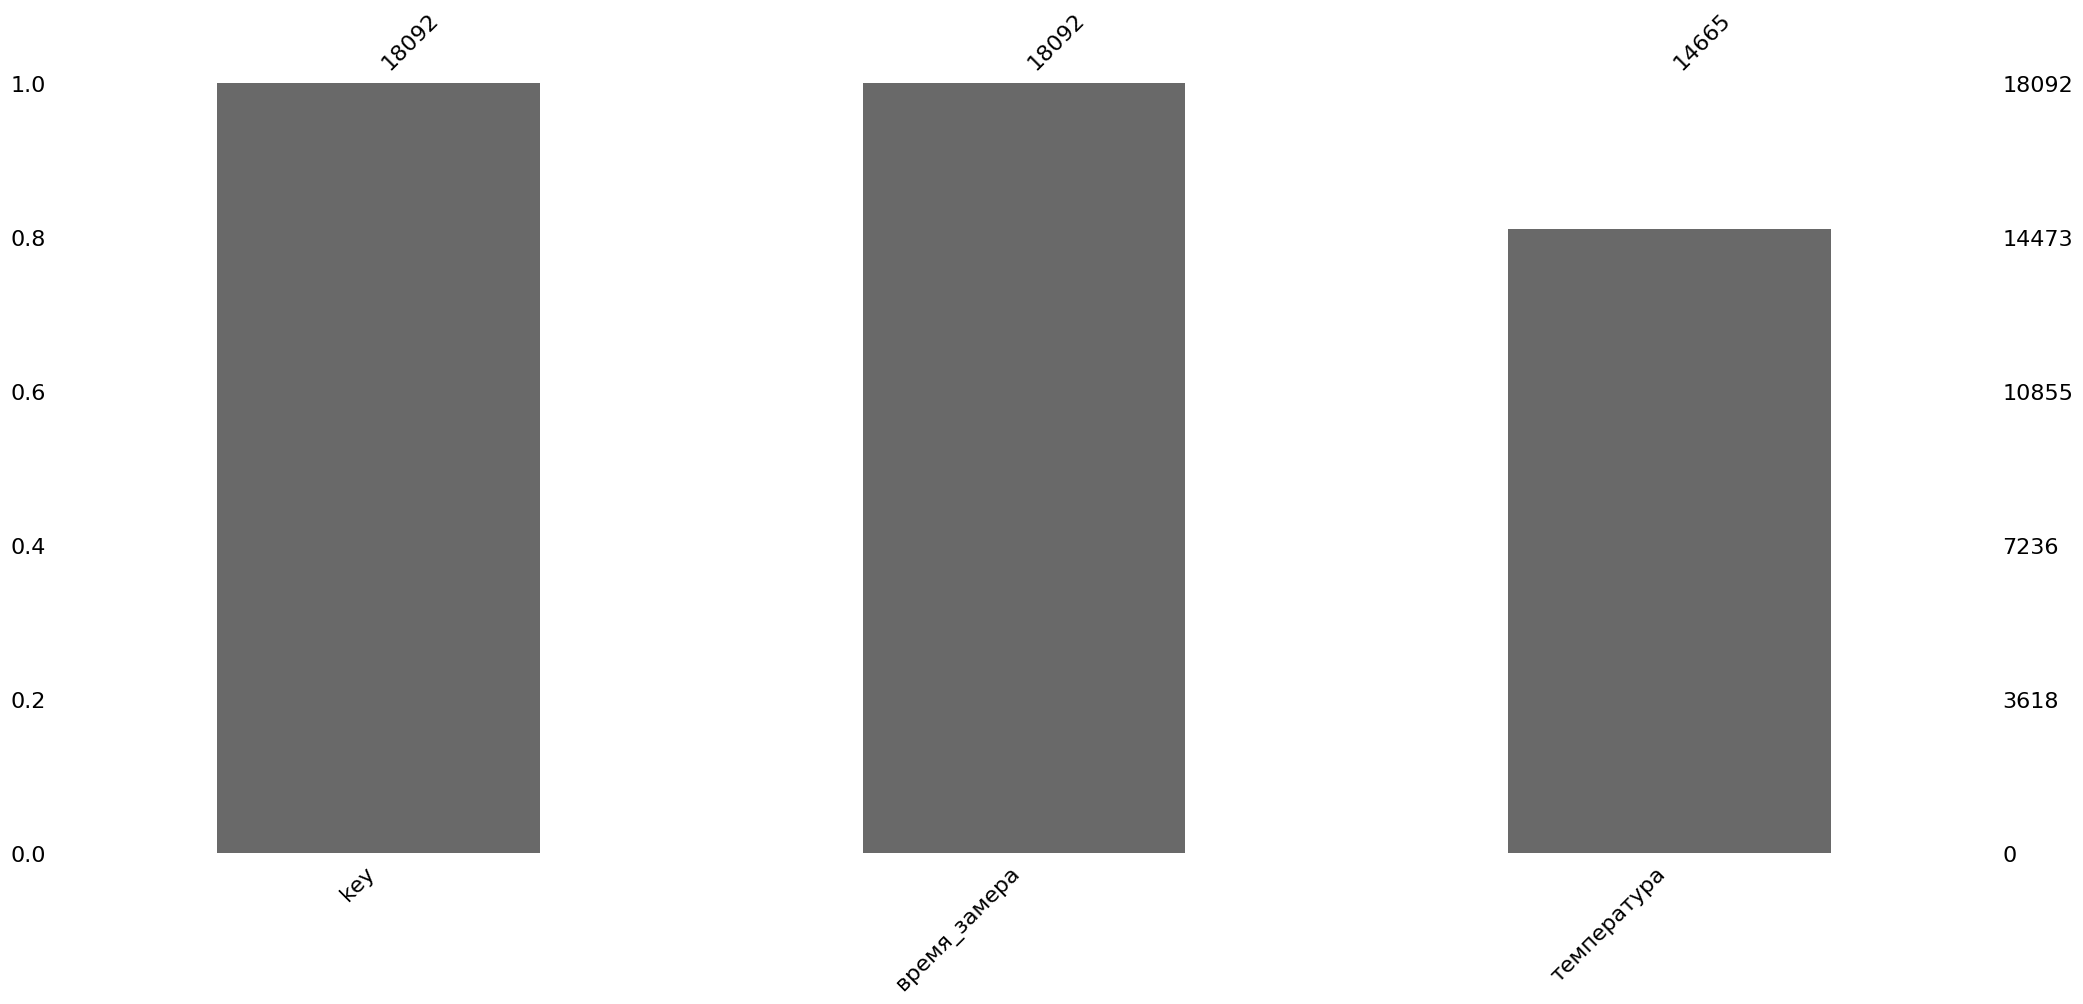

2026-03-05 10:50:24 [INFO] __main__: Характеристики базы данных


,count,mean,std,min,25%,50%,75%,max
key,18092.0,1616.460977,934.641385,1.0,807.75,1618.0,2429.0,3241.0


In [55]:
df_temp = check_data(df_temp)

У времени сделать нормальный тип данных  
Пропуски мы не сможем адекватно скорректировать  
Как эксперимент можем взять два соседних тайминга и просто взять среднюю между этими числами, критической проблемы тут быть не должно  
PS: изучив данные мы видим, что там на каждый key только один замер температур

In [56]:
# df_temp['температура'] = df_temp['температура'].fillna(-1).astype('float64')
df_temp['температура'] = df_temp['температура'].astype('float64')

In [57]:
df_temp['время_замера'] = df_temp['время_замера'].astype('datetime64[ns]')

In [58]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18092 entries, 0 to 18091
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   key           18092 non-null  int64         
 1   время_замера  18092 non-null  datetime64[ns]
 2   температура   14665 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 424.2 KB


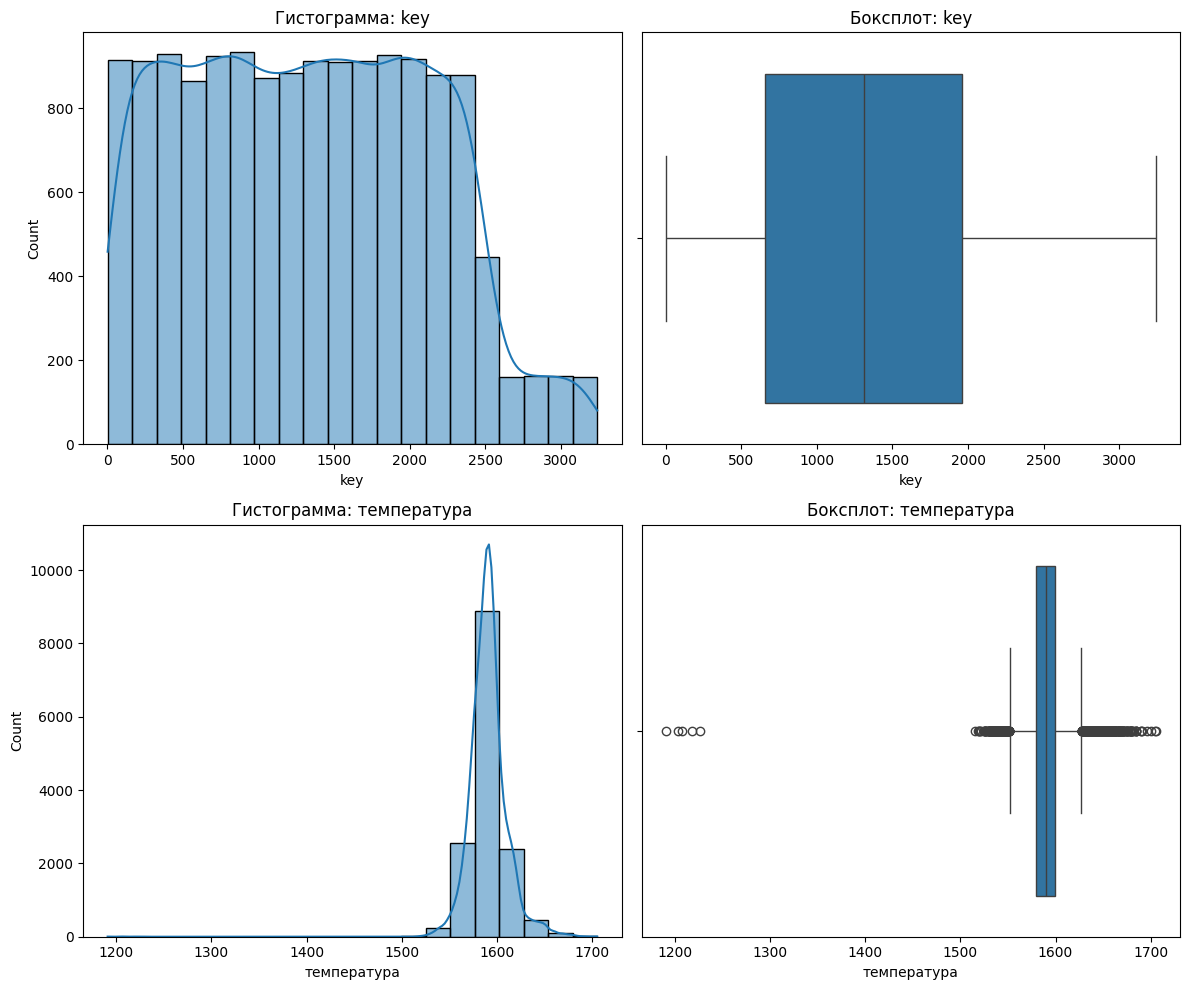

In [59]:
temp_df_temp = df_temp[df_temp['температура'] > 0]
plot_combined(temp_df_temp, col=None, target=None, col_type=None, legend_loc='best')

In [60]:
temp_df_temp.describe().T

,count,mean,min,25%,50%,75%,max,std
key,14665.0,1325.484214,1.0,654.0,1314.0,1963.0,3241.0,787.375969
время_замера,14665,2019-06-23 23:59:11.606341632,2019-05-03 11:02:04,2019-05-28 23:56:49,2019-06-21 22:55:49,2019-07-21 22:58:20,2019-09-06 16:48:55,NaN
температура,14665.0,1590.722741,1191.0,1580.0,1590.0,1599.0,1705.0,20.394381


В целом распределение температур выглядит адекватно

Что касается задания -  
1) таргет - последняя температура партии  
2) можно брать только те позиции, где есть начальная и конечная температура, т.е. минимум 2 позиции  
3) промежуточные - не брать, это утечка данных  
4) температура ниже 1500 - аномалия

In [61]:
# посмотрим исходя из вводных от заказчика
# уберем сразу аномалии
df_temp = df_temp[df_temp['температура'] >= 1500]

Находим ключи, у которых 2 и более записей, т.к. это требования по ТЗ

In [62]:
df_temp = df_temp.sort_values(['key', 'время_замера'])

valid_keys = df_temp.groupby('key').size()
valid_keys = valid_keys[valid_keys >= 2].index
df_temp_filtered = df_temp[df_temp['key'].isin(valid_keys)]

df_temp_agg = df_temp_filtered.groupby('key').agg(
    время_первого_замера=('время_замера', 'first'),
    время_последнего_замера=('время_замера', 'last'),
    стартовая_температура=('температура', 'first'),
    конечная_температура=('температура', 'last')
).reset_index()

display(df_temp_agg.head())

,key,время_первого_замера,время_последнего_замера,стартовая_температура,конечная_температура
0,1,2019-05-03 11:02:04,2019-05-03 11:30:38,1571.0,1613.0
1,2,2019-05-03 11:34:04,2019-05-03 11:55:09,1581.0,1602.0
2,3,2019-05-03 12:06:44,2019-05-03 12:35:57,1596.0,1599.0
3,4,2019-05-03 12:39:27,2019-05-03 12:59:47,1601.0,1625.0
4,5,2019-05-03 13:11:03,2019-05-03 13:36:39,1576.0,1602.0


In [63]:
df_temp = df_temp_agg
display(df_temp)

,key,время_первого_замера,время_последнего_замера,стартовая_температура,конечная_температура
0,1,2019-05-03 11:02:04,2019-05-03 11:30:38,1571.0,1613.0
1,2,2019-05-03 11:34:04,2019-05-03 11:55:09,1581.0,1602.0
2,3,2019-05-03 12:06:44,2019-05-03 12:35:57,1596.0,1599.0
3,4,2019-05-03 12:39:27,2019-05-03 12:59:47,1601.0,1625.0
4,5,2019-05-03 13:11:03,2019-05-03 13:36:39,1576.0,1602.0
...,...,...,...,...,...
2470,2495,2019-08-10 11:27:47,2019-08-10 11:50:47,1570.0,1591.0
2471,2496,2019-08-10 11:56:48,2019-08-10 12:25:13,1554.0,1591.0
2472,2497,2019-08-10 12:37:26,2019-08-10 12:53:28,1571.0,1589.0
2473,2498,2019-08-10 12:58:11,2019-08-10 13:23:31,1591.0,1594.0


##### df_wire

2026-03-05 10:50:24 [INFO] __main__: Общая информация базы данных


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3081 non-null   int64  
 1   wire_1  3055 non-null   float64
 2   wire_2  1079 non-null   object 
 3   wire_3  63 non-null     object 
 4   wire_4  14 non-null     object 
 5   wire_5  1 non-null      object 
 6   wire_6  73 non-null     object 
 7   wire_7  11 non-null     object 
 8   wire_8  19 non-null     object 
 9   wire_9  29 non-null     object 
dtypes: float64(1), int64(1), object(8)
memory usage: 240.8+ KB


None

2026-03-05 10:50:24 [INFO] __main__: 5 случайных строк


,key,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9
1688,1775,145.126801,None,None,None,None,None,None,None,None
795,849,140.119202,None,None,None,None,None,None,None,None
2287,2411,43.024799,60.078716,None,None,None,None,None,None,None
2942,3101,123.221275,None,None,None,None,None,None,None,None
1578,1658,105.066002,None,None,None,None,None,None,None,None


2026-03-05 10:50:24 [INFO] __main__: Число пропусков в базе данных


wire_1      26
wire_2    2002
wire_3    3018
wire_4    3067
wire_5    3080
wire_6    3008
wire_7    3070
wire_8    3062
wire_9    3052
dtype: int64

None

2026-03-05 10:50:24 [INFO] __main__: Визуализация пропусков


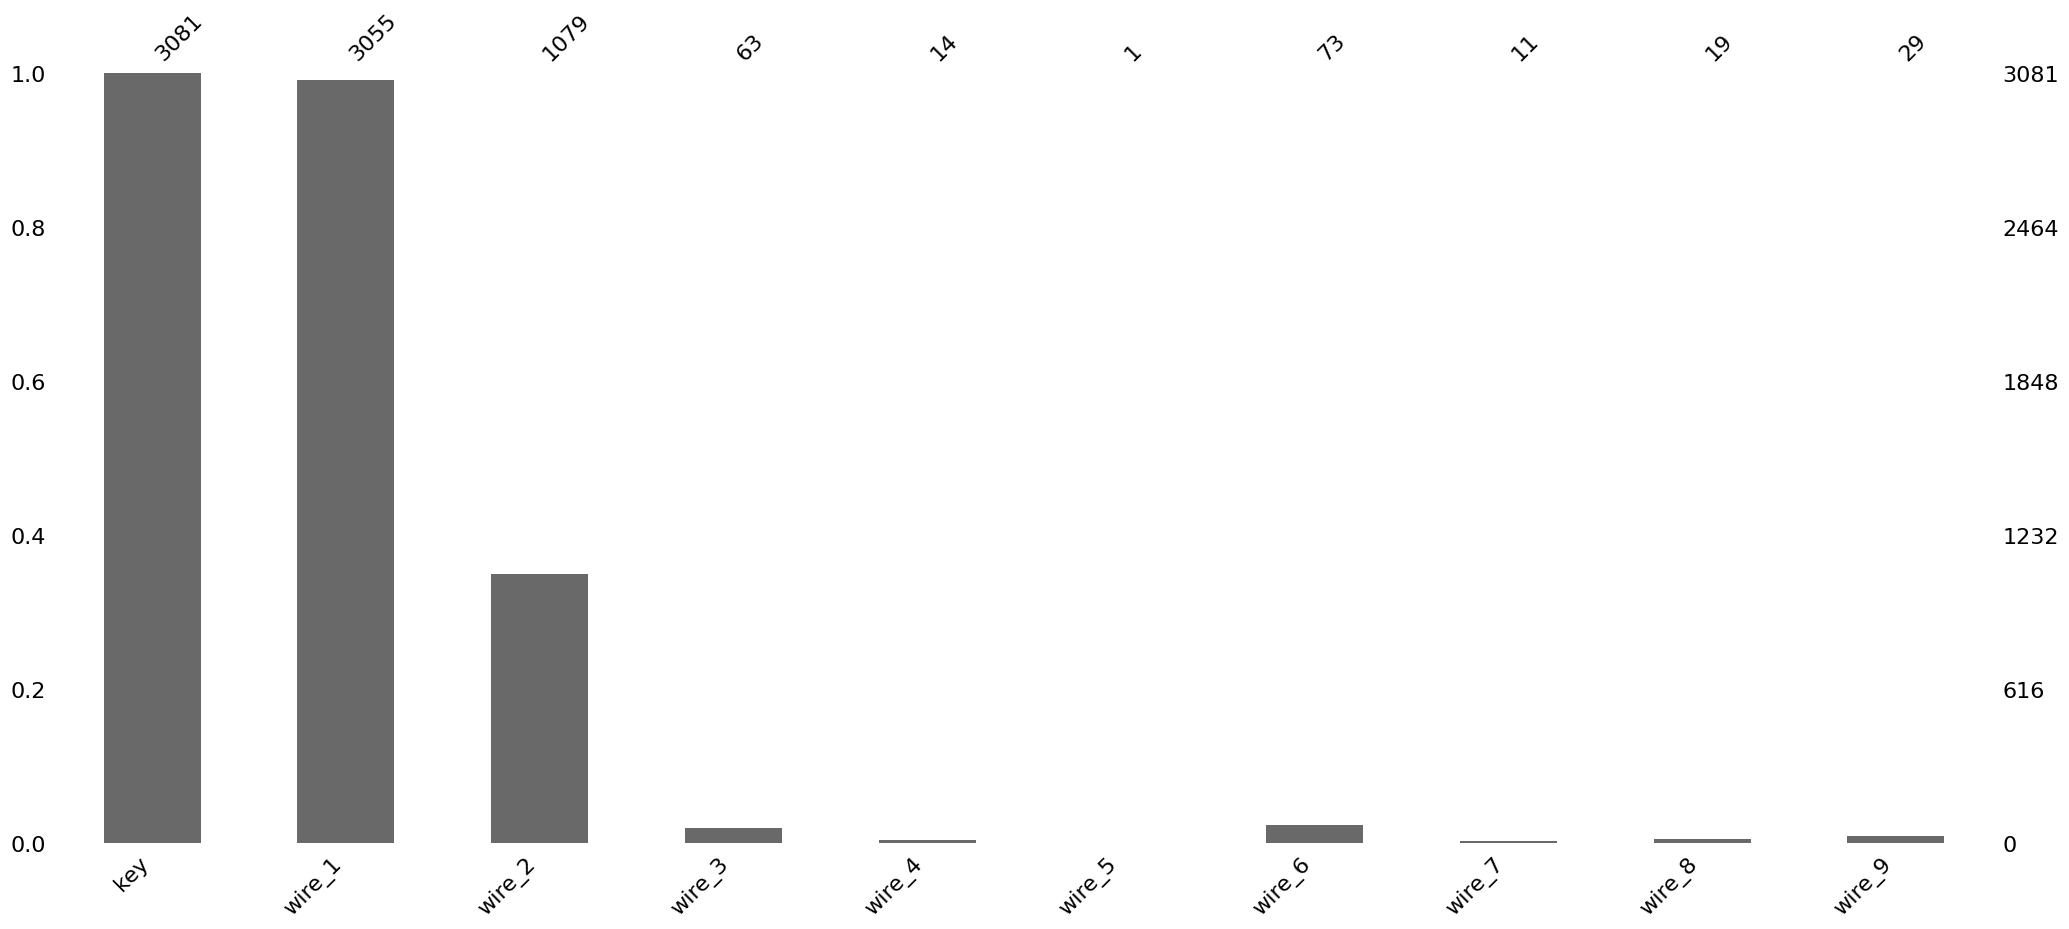

2026-03-05 10:50:25 [INFO] __main__: Характеристики базы данных


,count,mean,std,min,25%,50%,75%,max
key,3081.0,1623.426485,932.996726,1.0000,823.000000,1619.000000,2434.000000,3241.000000
wire_1,3055.0,100.895853,42.012518,1.9188,72.115684,100.158234,126.060483,330.314424


In [64]:
df_wire = check_data(df_wire)

Тут как и с сыпучими материалами - либо добавили, либо нет.  
Вместо пропусков - 0

In [65]:
for col in df_wire.columns:
    if col != 'key':
        df_wire[col] = df_wire[col].astype(float)

In [66]:
# сразу добавим общуюю массу добавок
wire_cols = [col for col in df_wire.columns if 'wire_' in col.lower()]
df_wire['total_wire'] = df_wire[wire_cols].sum(axis=1)

In [67]:
df_wire['count_wire'] = df_wire[wire_cols].count(axis=1)

In [68]:
df_wire.head()

,key,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9,total_wire,count_wire
0,1,60.059998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.059998,1
1,2,96.052315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.052315,1
2,3,91.160157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,91.160157,1
3,4,89.063515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.063515,1
4,5,89.238236,9.11456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.352796,2


In [69]:
df_wire = clear_df_missing_cols(df_wire)

2026-03-05 10:50:25 [INFO] __main__: Удалено признаков: 8
2026-03-05 10:50:25 [INFO] __main__: Осталось признаков: 4


2026-03-05 10:50:25 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-05 10:50:25 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


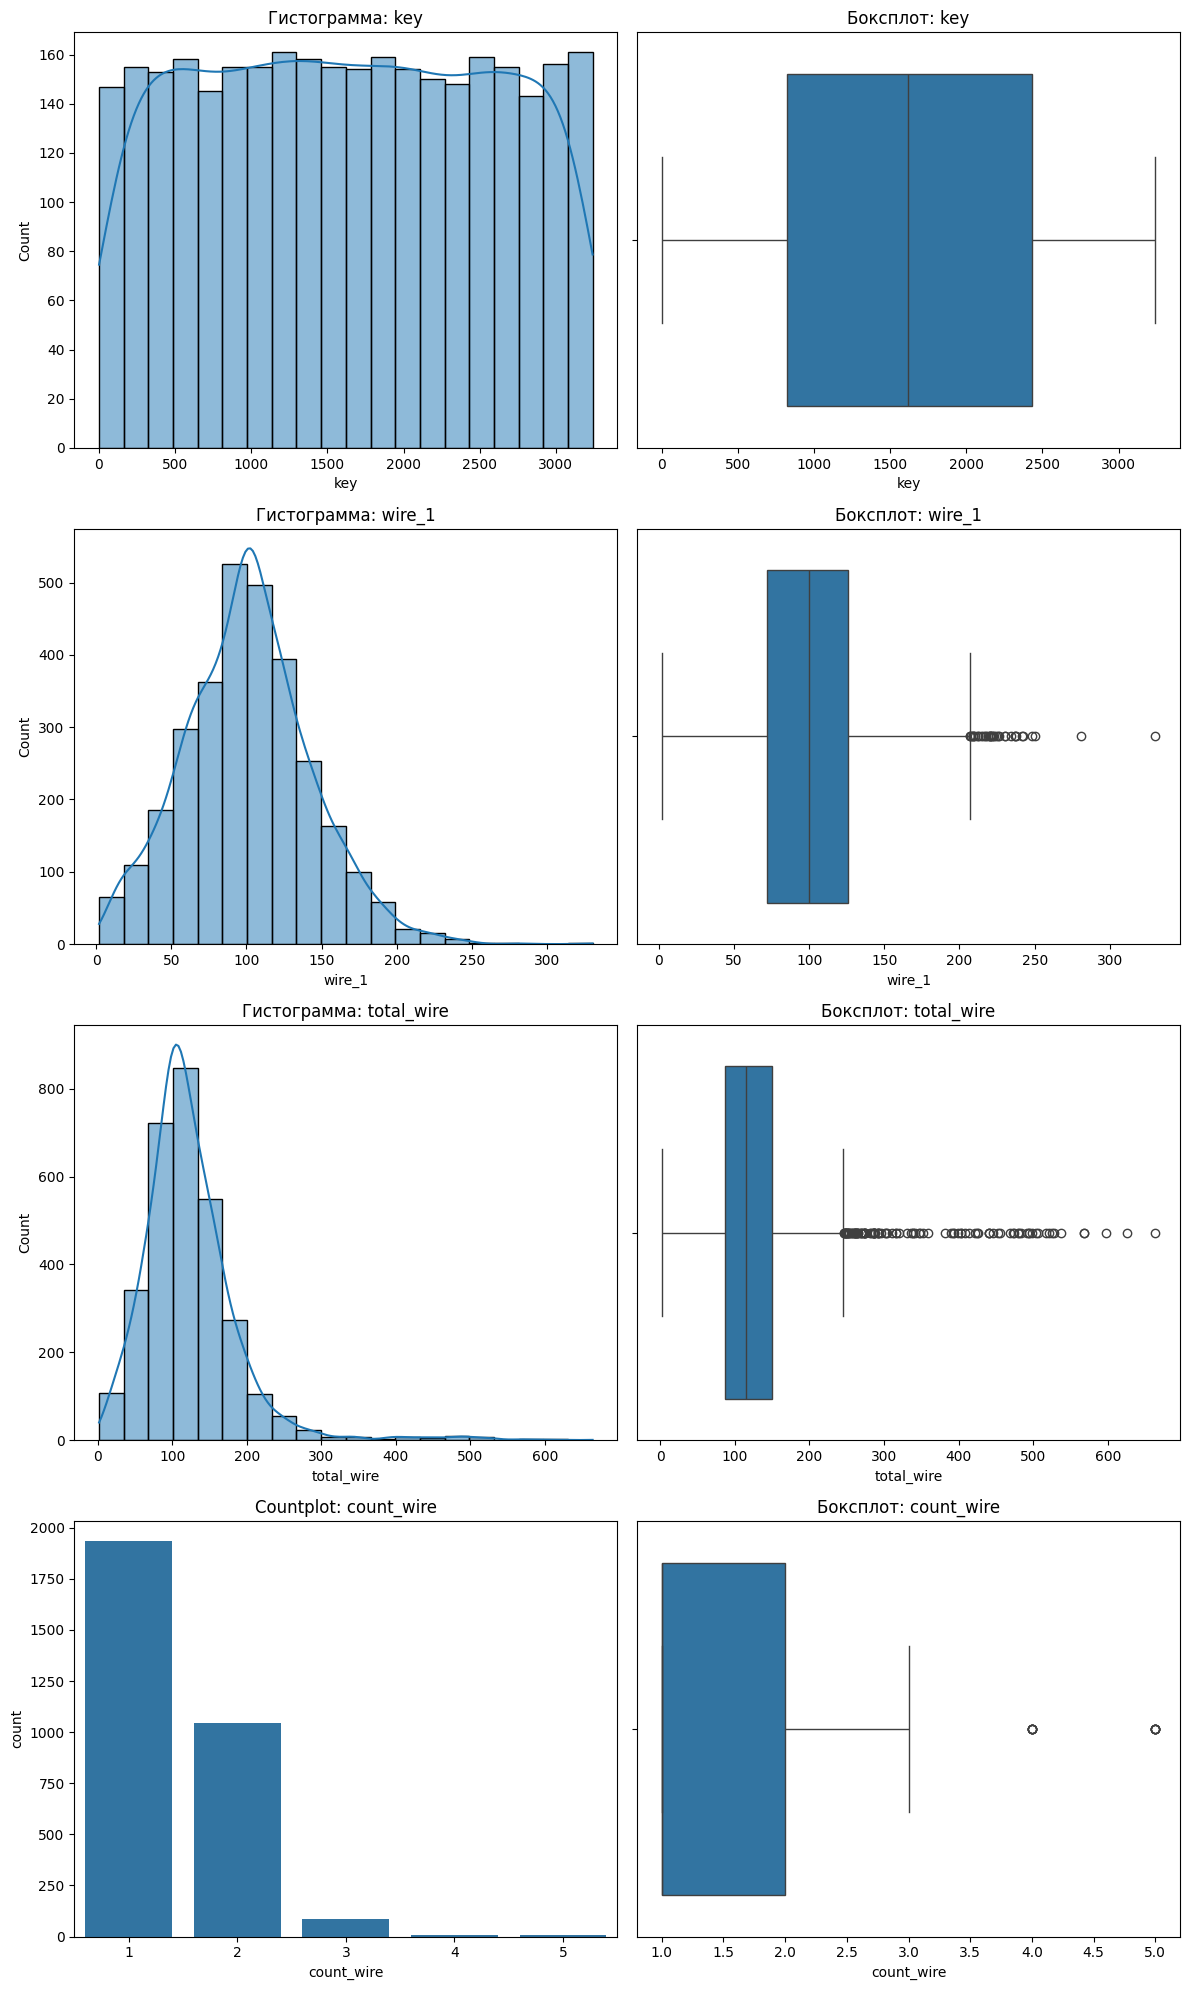

In [70]:
plot_combined(df_wire, col=None, target=None, col_type=None, legend_loc='best')

In [71]:
display(df_wire.info())
display(df_wire.head())
display(df_wire.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   key         3081 non-null   int64  
 1   wire_1      3055 non-null   float64
 2   total_wire  3081 non-null   float64
 3   count_wire  3081 non-null   int64  
dtypes: float64(2), int64(2)
memory usage: 96.4 KB


None

,key,wire_1,total_wire,count_wire
0,1,60.059998,60.059998,1
1,2,96.052315,96.052315,1
2,3,91.160157,91.160157,1
3,4,89.063515,89.063515,1
4,5,89.238236,98.352796,2


,count,mean,std,min,25%,50%,75%,max
key,3081.0,1623.426485,932.996726,1.0000,823.000000,1619.000000,2434.000000,3241.000000
wire_1,3055.0,100.895853,42.012518,1.9188,72.115684,100.158234,126.060483,330.314424
total_wire,3081.0,123.723326,66.082966,1.9188,86.112000,114.179523,150.181198,663.851766
count_wire,3081.0,1.409932,0.578078,1.0000,1.000000,1.000000,2.000000,5.000000


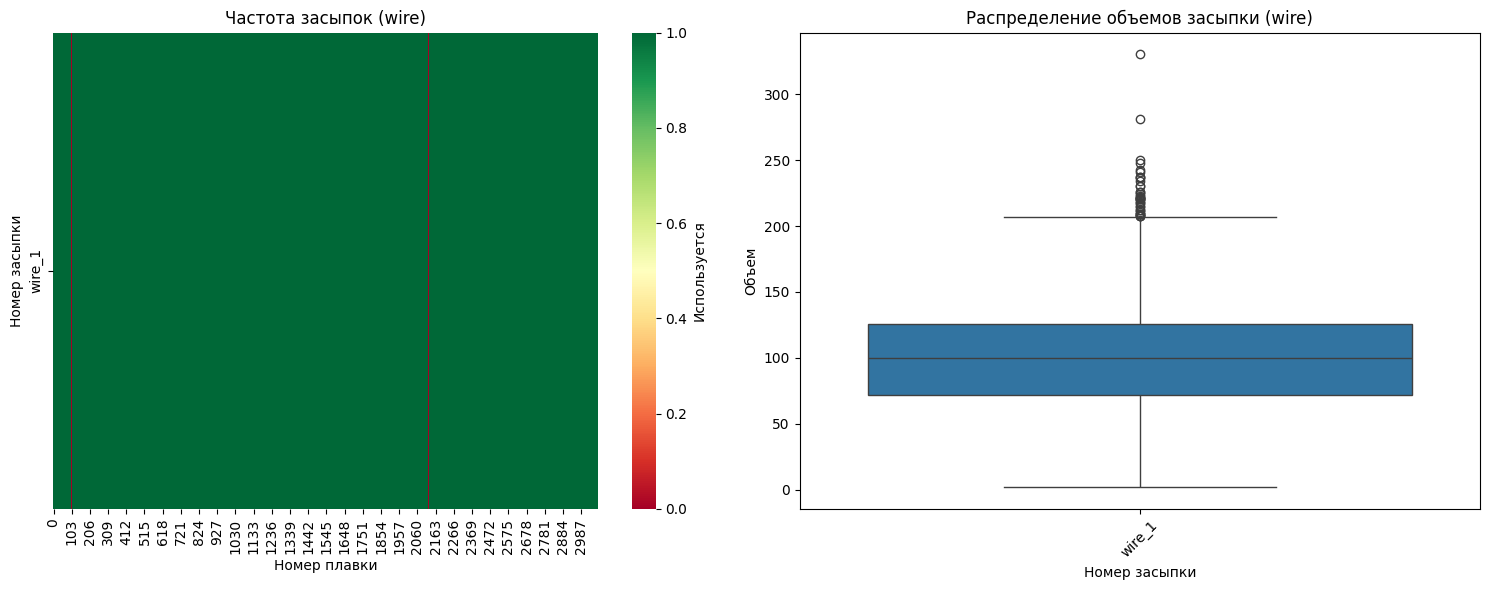

In [72]:
wire_cols = [col for col in df_wire.columns if col.startswith('wire_')]
wire_cols = sorted(wire_cols, key=lambda x: int(x.split('_')[1]))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Тепловая карта засыпок
usage_matrix = pd.DataFrame({col: (df_wire[col] > 0).astype(int) for col in wire_cols})
sns.heatmap(usage_matrix.T, cmap='RdYlGn', cbar_kws={'label': 'Используется'}, ax=axes[0])
axes[0].set_title('Частота засыпок (wire)')
axes[0].set_xlabel('Номер плавки')
axes[0].set_ylabel('Номер засыпки')

# Распределение объемов
data_for_box = df_wire[wire_cols].melt(var_name='Номер засыпки', value_name='Объем')
data_for_box = data_for_box[data_for_box['Объем'] > 0]
sns.boxplot(data=data_for_box, x='Номер засыпки', y='Объем', ax=axes[1])
# axes[1].set_yscale('log')
axes[1].set_title('Распределение объемов засыпки (wire)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Выборсы конечно же есть, но берем в расчте, что так надо  
В целом видно, что основная масса грузится в первые 2-3 этапа, а дальше уже мелкие корректировки

In [73]:
# Добьем нулями
# df_wire = df_wire.fillna(0)

##### df_wire_time

2026-03-05 10:50:26 [INFO] __main__: Общая информация базы данных


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   key     3081 non-null   int64 
 1   wire_1  3055 non-null   object
 2   wire_2  1079 non-null   object
 3   wire_3  63 non-null     object
 4   wire_4  14 non-null     object
 5   wire_5  1 non-null      object
 6   wire_6  73 non-null     object
 7   wire_7  11 non-null     object
 8   wire_8  19 non-null     object
 9   wire_9  29 non-null     object
dtypes: int64(1), object(9)
memory usage: 240.8+ KB


None

2026-03-05 10:50:26 [INFO] __main__: 5 случайных строк


,key,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9
3031,3190,2019-09-04 23:03:09,2019-09-04 22:56:51,None,None,None,None,None,None,None
924,984,2019-06-10 11:08:47,None,None,None,None,None,None,None,None
102,118,None,None,2019-05-07 23:37:44,2019-05-07 23:21:42,None,2019-05-07 23:01:42,None,None,None
2057,2155,2019-07-29 10:52:15,None,None,None,None,None,None,None,None
247,270,2019-05-14 01:01:34,2019-05-14 00:52:16,None,None,None,None,None,None,None


2026-03-05 10:50:26 [INFO] __main__: Число пропусков в базе данных


wire_1      26
wire_2    2002
wire_3    3018
wire_4    3067
wire_5    3080
wire_6    3008
wire_7    3070
wire_8    3062
wire_9    3052
dtype: int64

None

2026-03-05 10:50:26 [INFO] __main__: Визуализация пропусков


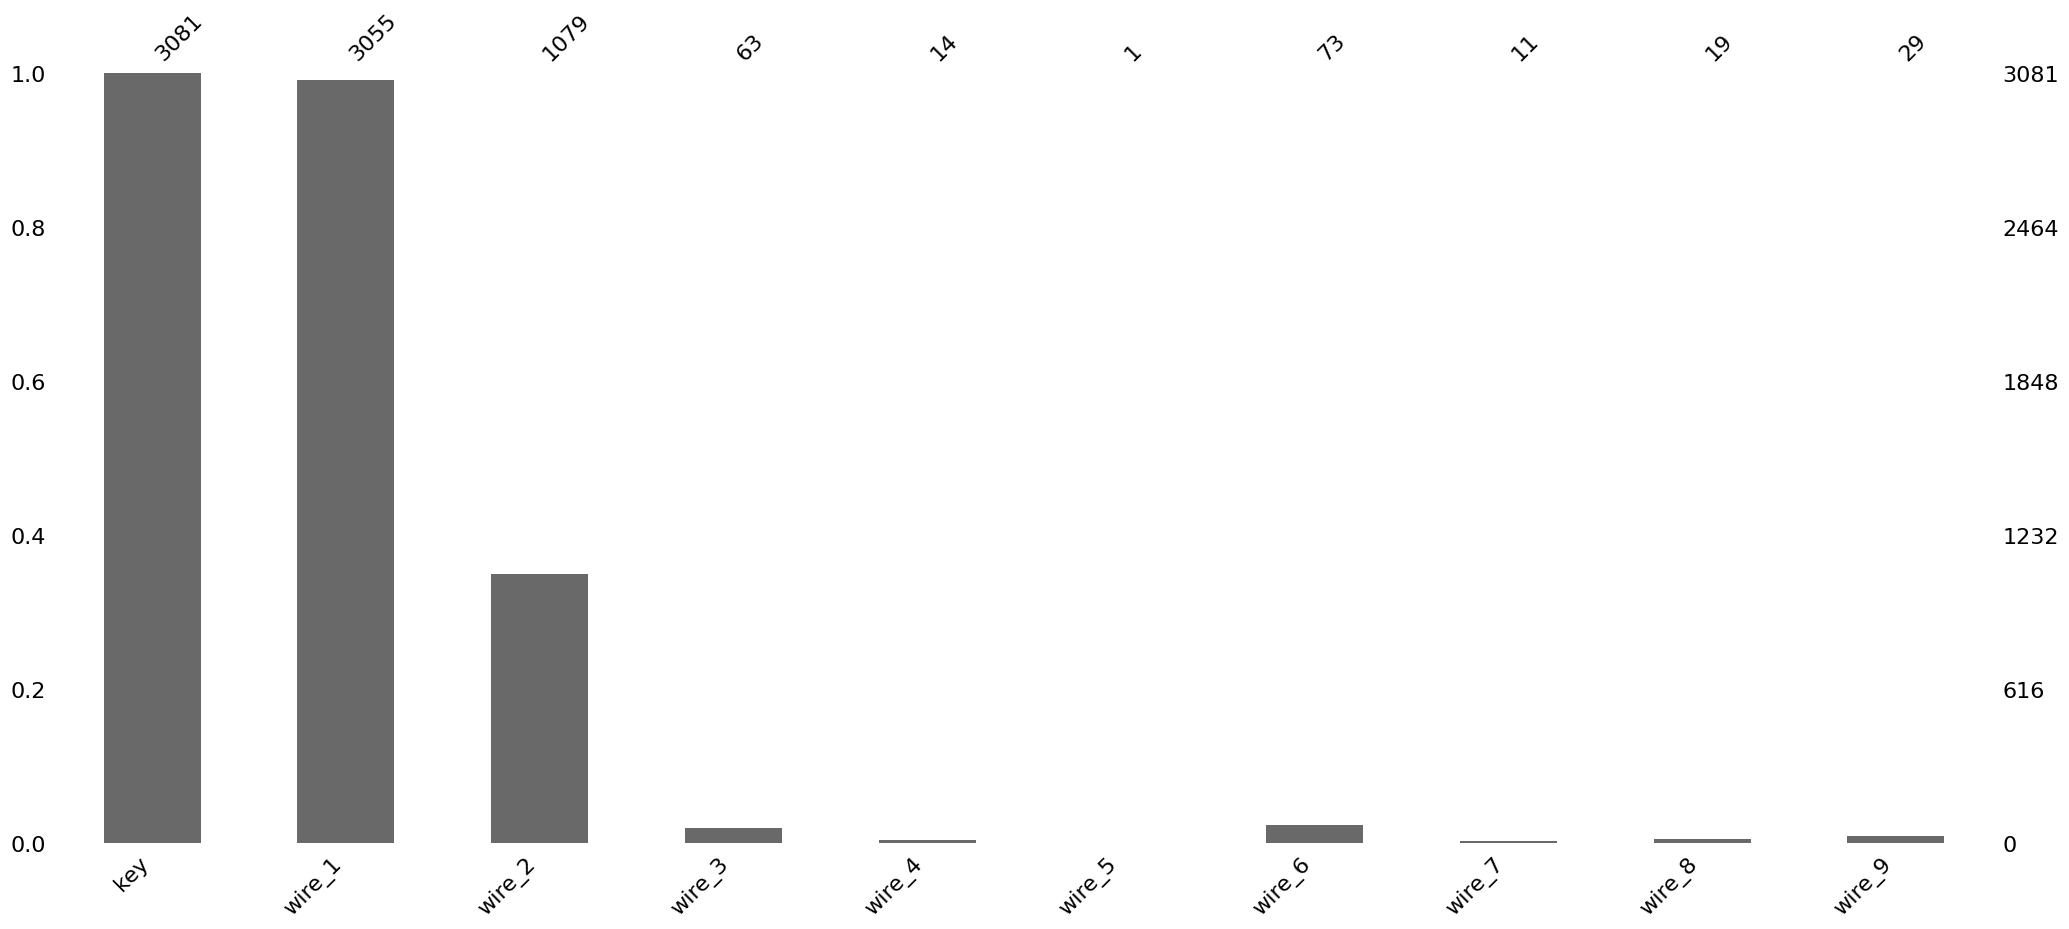

2026-03-05 10:50:26 [INFO] __main__: Характеристики базы данных


,count,mean,std,min,25%,50%,75%,max
key,3081.0,1623.426485,932.996726,1.0,823.0,1619.0,2434.0,3241.0


In [74]:
df_wire_time = check_data(df_wire_time)

In [75]:
df_wire_time = clear_df_missing_cols(df_wire_time)

2026-03-05 10:50:26 [INFO] __main__: Удалено признаков: 8
2026-03-05 10:50:26 [INFO] __main__: Осталось признаков: 2


In [76]:
wire_time_cols = [col for col in df_wire_time.columns if 'wire_' in col.lower()]
df_wire_time[wire_time_cols] = df_wire_time[wire_time_cols].astype('datetime64[ns]')

In [77]:
df_wire_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   key     3081 non-null   int64         
 1   wire_1  3055 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(1)
memory usage: 48.3 KB


In [78]:
# если засыпок >2 то сделаем новые признаки
wire_time_cols = [col for col in df_wire_time.columns if col.startswith('wire_')]
wire_time_cols = sorted(wire_time_cols, key=lambda x: int(x.split('_')[1]))

In [79]:
if len(wire_time_cols) >= 2:
    df_wire_time['начало_засыпок'] = df_wire_time[wire_time_cols].min(axis=1)
    df_wire_time['конец_засыпок'] = df_wire_time[wire_time_cols].max(axis=1)
    df_wire_time['общее_время_засыпок'] = (df_wire_time['конец_засыпок'] - df_wire_time['начало_засыпок']).dt.total_seconds()
    
    # Средний интервал между подачами (если подач меньше двух, будет NaN)
    df_wire_time['интервал_подачи_avg'] = (
        df_wire_time[wire_time_cols]
        .apply(lambda row: row.dropna().sort_values().diff().dt.total_seconds().mean(), axis=1)
    )
else:
    logger.info("Недостаточно колонок wire_ для расчета признаков (нужно >=2). Пропускаем.")

2026-03-05 10:50:26 [INFO] __main__: Недостаточно колонок wire_ для расчета признаков (нужно >=2). Пропускаем.


In [80]:
display(df_wire_time.head())
display(df_wire_time.info())
display(df_wire_time.describe().T)

,key,wire_1
0,1,2019-05-03 11:06:19
1,2,2019-05-03 11:36:50
2,3,2019-05-03 12:11:46
3,4,2019-05-03 12:43:22
4,5,2019-05-03 13:20:44


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   key     3081 non-null   int64         
 1   wire_1  3055 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(1)
memory usage: 48.3 KB


None

,count,mean,min,25%,50%,75%,max,std
key,3081.0,1623.426485,1.0,823.0,1619.0,2434.0,3241.0,932.996726
wire_1,3055,2019-07-05 23:22:34.279541760,2019-05-03 11:06:19,2019-06-04 19:30:11.500000,2019-07-03 06:36:23,2019-08-08 08:56:06.500000,2019-09-06 17:10:06,NaN


In [81]:
# и посмотрим что вышло
if len(wire_time_cols) >= 2:
    cols = ['общее_время_засыпок', 'интервал_подачи_avg']
    plot_combined(df_wire_time, col=cols, target=None, col_type=None, legend_loc='best')

Где-то большие промежутки и общее время плавки добавок, но штош поделать...

##### Выводы

Все данные были изучены и проанализированы  
Обработаны пропуски  
Скорректированы типы данных  
Реализованы новые признаки  

#### Объединение данных

##### Объединение

In [82]:
df_merged = (
    df_temp
    .merge(df_arc, on='key', how='inner')
    .merge(df_bulk, on='key', how='inner')
    .merge(df_bulk_time, on='key', how='inner', suffixes=('', '_bulk_time'))
    .merge(df_gas, on='key', how='inner')
    .merge(df_wire, on='key', how='inner')
    .merge(df_wire_time, on='key', how='inner', suffixes=('', '_wire_time'))
)

In [83]:
display(df_merged.drop_duplicates())

,key,время_первого_замера,время_последнего_замера,стартовая_температура,конечная_температура,количество_нагревов,суммарная_длительность,средняя_длительность,максимальная_длительность,средняя_активная_мощность,...,bulk_15_bulk_time,начало_засыпок,конец_засыпок,общее_время_засыпок,интервал_подачи_avg,газ_1,wire_1,total_wire,count_wire,wire_1_wire_time
0,1,2019-05-03 11:02:04,2019-05-03 11:30:38,1571.0,1613.0,5,1098.0,219.600000,365.0,0.607346,...,2019-05-03 11:10:43,2019-05-03 11:10:43,2019-05-03 11:24:31,828.0,414.0,29.749986,60.059998,60.059998,1,2019-05-03 11:06:19
1,2,2019-05-03 11:34:04,2019-05-03 11:55:09,1581.0,1602.0,4,811.0,202.750000,338.0,0.534852,...,2019-05-03 11:44:39,2019-05-03 11:44:39,2019-05-03 11:53:30,531.0,265.5,12.555561,96.052315,96.052315,1,2019-05-03 11:36:50
2,3,2019-05-03 12:06:44,2019-05-03 12:35:57,1596.0,1599.0,5,655.0,131.000000,280.0,0.812728,...,2019-05-03 12:16:16,2019-05-03 12:16:16,2019-05-03 12:27:13,657.0,328.5,28.554793,91.160157,91.160157,1,2019-05-03 12:11:46
3,4,2019-05-03 12:39:27,2019-05-03 12:59:47,1601.0,1625.0,4,741.0,185.250000,278.0,0.676622,...,2019-05-03 12:46:36,2019-05-03 12:46:36,2019-05-03 12:58:00,684.0,342.0,18.841219,89.063515,89.063515,1,2019-05-03 12:43:22
4,5,2019-05-03 13:11:03,2019-05-03 13:36:39,1576.0,1602.0,4,869.0,217.250000,415.0,0.563238,...,2019-05-03 13:30:47,2019-05-03 13:30:47,2019-05-03 13:34:12,205.0,102.5,5.413692,89.238236,98.352796,2,2019-05-03 13:20:44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2324,2495,2019-08-10 11:27:47,2019-08-10 11:50:47,1570.0,1591.0,4,723.0,180.750000,234.0,0.792033,...,2019-08-10 11:37:27,2019-08-10 11:37:27,2019-08-10 11:48:22,655.0,327.5,7.125735,89.150879,89.150879,1,2019-08-10 11:31:40
2325,2496,2019-08-10 11:56:48,2019-08-10 12:25:13,1554.0,1591.0,6,940.0,156.666667,228.0,0.695820,...,2019-08-10 12:03:50,2019-08-10 12:03:50,2019-08-10 12:12:32,522.0,261.0,9.412616,114.179527,114.179527,1,2019-08-10 11:59:10
2326,2497,2019-08-10 12:37:26,2019-08-10 12:53:28,1571.0,1589.0,3,569.0,189.666667,207.0,1.201746,...,2019-08-10 12:51:38,2019-08-10 12:40:30,2019-08-10 12:51:38,668.0,334.0,6.271699,94.086723,103.134723,2,2019-08-10 12:46:10
2327,2498,2019-08-10 12:58:11,2019-08-10 13:23:31,1591.0,1594.0,5,750.0,150.000000,256.0,0.640462,...,2019-08-10 13:07:38,2019-08-10 13:07:38,2019-08-10 13:16:31,533.0,266.5,14.953657,118.110717,118.110717,1,2019-08-10 13:02:54


Надо бы удалить временнЫе столбцы... они нам не понадобятся

In [84]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2329 entries, 0 to 2328
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   key                             2329 non-null   int64         
 1   время_первого_замера            2329 non-null   datetime64[ns]
 2   время_последнего_замера         2329 non-null   datetime64[ns]
 3   стартовая_температура           2329 non-null   float64       
 4   конечная_температура            2329 non-null   float64       
 5   количество_нагревов             2329 non-null   int64         
 6   суммарная_длительность          2329 non-null   float64       
 7   средняя_длительность            2329 non-null   float64       
 8   максимальная_длительность       2329 non-null   float64       
 9   средняя_активная_мощность       2329 non-null   float64       
 10  максимальная_активная_мощность  2329 non-null   float64       
 11  сред

In [85]:
non_datetime_cols = df_merged.select_dtypes(exclude=['datetime64[ns]']).columns
main_df = df_merged[non_datetime_cols].copy()

In [86]:
main_df.head()

,key,стартовая_температура,конечная_температура,количество_нагревов,суммарная_длительность,средняя_длительность,максимальная_длительность,средняя_активная_мощность,максимальная_активная_мощность,средняя_реактивная_мощность,...,bulk_14,bulk_15,total_bulk,count_bulk,общее_время_засыпок,интервал_подачи_avg,газ_1,wire_1,total_wire,count_wire
0,1,1571.0,1613.0,5,1098.0,219.60,365.0,0.607346,0.867133,0.428564,...,150.0,154.0,510.0,3,828.0,414.0,29.749986,60.059998,60.059998,1
1,2,1581.0,1602.0,4,811.0,202.75,338.0,0.534852,0.786322,0.363339,...,149.0,154.0,509.0,3,531.0,265.5,12.555561,96.052315,96.052315,1
2,3,1596.0,1599.0,5,655.0,131.00,280.0,0.812728,1.222963,0.587491,...,152.0,153.0,510.0,3,657.0,328.5,28.554793,91.160157,91.160157,1
3,4,1601.0,1625.0,4,741.0,185.25,278.0,0.676622,0.887855,0.514248,...,153.0,154.0,514.0,3,684.0,342.0,18.841219,89.063515,89.063515,1
4,5,1576.0,1602.0,4,869.0,217.25,415.0,0.563238,0.892957,0.421998,...,151.0,152.0,506.0,3,205.0,102.5,5.413692,89.238236,98.352796,2


In [87]:
# попробуем дополнительно залогарифмировать признаки
numeric_cols = main_df.select_dtypes(include=[np.number]).columns.tolist()
if 'key' in numeric_cols:
    numeric_cols.remove('key')

skewness = main_df[numeric_cols].apply(lambda x: skew(x.dropna()))
skewed_features = skewness[abs(skewness) > 1].index.tolist()
display('Скошенные признаки (|skew|>1):', skewed_features)

for col in skewed_features:
    main_df[f'log_{col}'] = np.log1p(main_df[col])
    display(f'Создан log_{col}')

'Скошенные признаки (|skew|>1):'

['суммарная_длительность',
 'максимальная_длительность',
 'bulk_12',
 'bulk_14',
 'count_bulk',
 'общее_время_засыпок',
 'интервал_подачи_avg',
 'газ_1',
 'total_wire',
 'count_wire']

'Создан log_суммарная_длительность'

'Создан log_максимальная_длительность'

'Создан log_bulk_12'

...

'Создан log_общее_время_засыпок'

'Создан log_интервал_подачи_avg'

'Создан log_газ_1'

'Создан log_total_wire'

'Создан log_count_wire'

In [88]:
main_df = main_df.fillna(0)

In [89]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2329 entries, 0 to 2328
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   key                             2329 non-null   int64  
 1   стартовая_температура           2329 non-null   float64
 2   конечная_температура            2329 non-null   float64
 3   количество_нагревов             2329 non-null   int64  
 4   суммарная_длительность          2329 non-null   float64
 5   средняя_длительность            2329 non-null   float64
 6   максимальная_длительность       2329 non-null   float64
 7   средняя_активная_мощность       2329 non-null   float64
 8   максимальная_активная_мощность  2329 non-null   float64
 9   средняя_реактивная_мощность     2329 non-null   float64
 10  bulk_12                         2329 non-null   float64
 11  bulk_14                         2329 non-null   float64
 12  bulk_15                         23

##### Исследуем итоговую таблицу

interval columns not set, guessing: ['стартовая_температура', 'конечная_температура', 'количество_нагревов', 'суммарная_длительность', 'средняя_длительность', 'максимальная_длительность', 'средняя_активная_мощность', 'максимальная_активная_мощность', 'средняя_реактивная_мощность', 'bulk_12', 'bulk_14', 'bulk_15', 'total_bulk', 'count_bulk', 'общее_время_засыпок', 'интервал_подачи_avg', 'газ_1', 'wire_1', 'total_wire', 'count_wire', 'log_суммарная_длительность', 'log_максимальная_длительность', 'log_bulk_12', 'log_bulk_14', 'log_count_bulk', 'log_общее_время_засыпок', 'log_интервал_подачи_avg', 'log_газ_1', 'log_total_wire', 'log_count_wire']


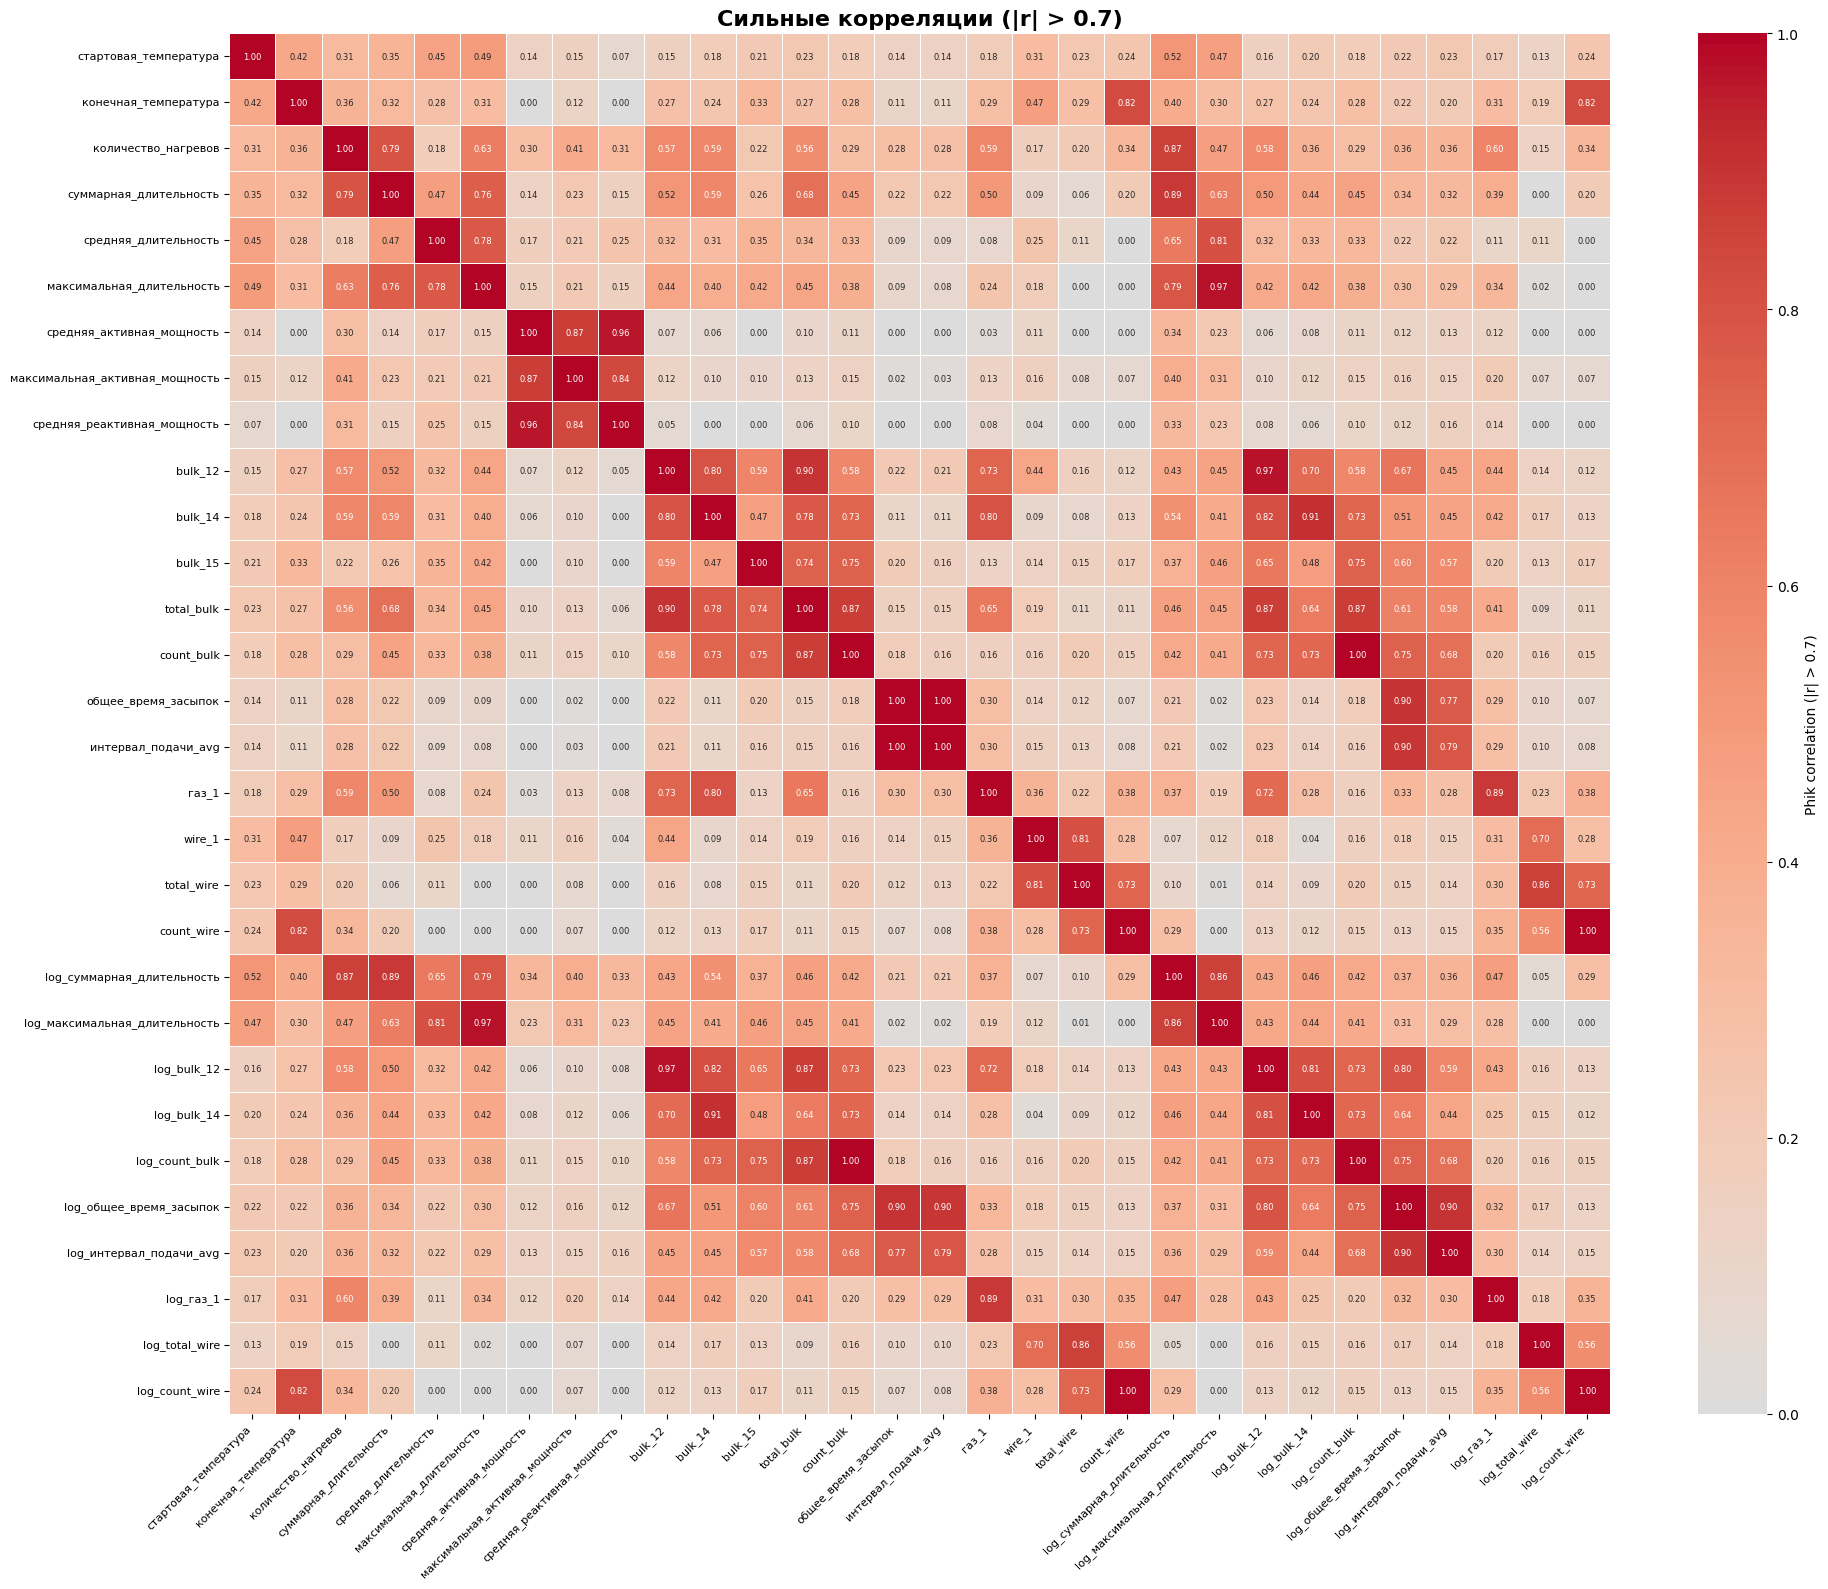

In [90]:
df_cor = main_df.drop(columns=['key'])
correlation_matrix = df_cor.phik_matrix()

plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            center=0,
            square=True, 
            linewidths=0.5,
            cbar_kws={'label': 'Phik correlation (|r| > 0.7)'},
            annot_kws={'size': 6})
plt.title('Сильные корреляции (|r| > 0.7)', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [91]:
threshold_cor = 0.9

features_to_drop = set()
corr_matrix = correlation_matrix.copy()
np.fill_diagonal(corr_matrix.values, 0)

for col in corr_matrix.columns:
    high_corr = corr_matrix[abs(corr_matrix[col]) > threshold_cor].index.tolist()
    if high_corr:
        features_to_drop.update(high_corr[1:])

logger.info(f"Удаляем признаков: {len(features_to_drop)}")
display("Список удаляемых признаков:", sorted(features_to_drop))

main_df = main_df.drop(columns=list(features_to_drop), errors='ignore')

logger.info(f"Осталось признаков: {main_df.shape[1] - 1}")

2026-03-05 10:50:31 [INFO] __main__: Удаляем признаков: 2


'Список удаляемых признаков:'

['log_bulk_12', 'log_общее_время_засыпок']

2026-03-05 10:50:31 [INFO] __main__: Осталось признаков: 28


In [92]:
# выведем корреляцию с таргетом
corr = correlation_matrix[TARGET].sort_values(ascending=False)

logger.info(f"Сильня корреляция с {TARGET}:")
display(corr[corr >= 0.9])

logger.info(f"Слабая корреляция с {TARGET}:")
display(corr[corr < 0.9])

2026-03-05 10:50:31 [INFO] __main__: Сильня корреляция с конечная_температура:


конечная_температура    1.0
Name: конечная_температура, dtype: float64

2026-03-05 10:50:31 [INFO] __main__: Слабая корреляция с конечная_температура:


count_wire                        0.824143
log_count_wire                    0.824143
wire_1                            0.470512
стартовая_температура             0.424898
log_суммарная_длительность        0.404829
количество_нагревов               0.360192
bulk_15                           0.329065
суммарная_длительность            0.317842
максимальная_длительность         0.309724
log_газ_1                         0.306806
log_максимальная_длительность     0.304627
газ_1                             0.290854
total_wire                        0.287175
log_count_bulk                    0.283846
count_bulk                        0.283846
средняя_длительность              0.279890
bulk_12                           0.274426
total_bulk                        0.268711
log_bulk_12                       0.265031
bulk_14                           0.241504
log_bulk_14                       0.238496
log_общее_время_засыпок           0.215112
log_интервал_подачи_avg           0.195609
log_total_w

In [ ]:
# Подготовка данных для VIF
vif_df = main_df.drop(columns=['key', TARGET])
vif_df = pd.get_dummies(vif_df, drop_first=True)
for col in vif_df.select_dtypes(include='bool').columns:
    vif_df[col] = vif_df[col].astype(int)
vif_df = vif_df.dropna()

# Список всех признаков
all_features = vif_df.columns.tolist()
features = all_features.copy()
threshold = 10

# Итеративное удаление признаков с VIF > threshold
while True:
    X_with_const = vif_df[features].assign(const=1)
    vif_vals = [variance_inflation_factor(X_with_const.values, i) for i in range(len(features))]
    max_vif = max(vif_vals)
    if max_vif <= threshold:
        break
    idx = vif_vals.index(max_vif)
    removed = features.pop(idx)
    logger.info(f"Удалён {removed} (VIF={max_vif:.2f})")

logger.info(f"Осталось признаков: {len(features)}")
logger.info(f"Список: {features}")

# Удаляем из main_df признаки, которые не прошли отбор
cols_to_drop = [col for col in all_features if col not in features]
if cols_to_drop:
    logger.info(f"Удаляем из main_df: {cols_to_drop}")
    main_df = main_df.drop(columns=cols_to_drop, errors='ignore')
else:
    logger.info("Ничего не удаляем, все признаки остались.")

2026-03-05 10:50:31 [INFO] __main__: Удалён bulk_12 (VIF=inf)
2026-03-05 10:50:31 [INFO] __main__: Удалён log_count_bulk (VIF=223.37)
2026-03-05 10:50:32 [INFO] __main__: Удалён count_wire (VIF=90.94)
2026-03-05 10:50:32 [INFO] __main__: Удалён интервал_подачи_avg (VIF=36.01)
2026-03-05 10:50:32 [INFO] __main__: Удалён log_максимальная_длительность (VIF=30.21)
2026-03-05 10:50:32 [INFO] __main__: Удалён количество_нагревов (VIF=28.62)
2026-03-05 10:50:32 [INFO] __main__: Удалён средняя_активная_мощность (VIF=16.26)
2026-03-05 10:50:32 [INFO] __main__: Удалён count_bulk (VIF=13.92)
2026-03-05 10:50:32 [INFO] __main__: Осталось признаков: 19
2026-03-05 10:50:32 [INFO] __main__: Список: ['стартовая_температура', 'суммарная_длительность', 'средняя_длительность', 'максимальная_длительность', 'максимальная_активная_мощность', 'средняя_реактивная_мощность', 'bulk_14', 'bulk_15', 'total_bulk', 'общее_время_засыпок', 'газ_1', 'wire_1', 'total_wire', 'log_суммарная_длительность', 'log_bulk_14', 

По VIF всё больно - и как хорошо, что у нас нет линеек, а для всего остальное VIF чистить нет смысла, но мы все равно почистим  
Дальше просто делим данные и переходим к обучению

## Подготовим данные для обучения

In [94]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2329 entries, 0 to 2328
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   key                             2329 non-null   int64  
 1   стартовая_температура           2329 non-null   float64
 2   конечная_температура            2329 non-null   float64
 3   суммарная_длительность          2329 non-null   float64
 4   средняя_длительность            2329 non-null   float64
 5   максимальная_длительность       2329 non-null   float64
 6   максимальная_активная_мощность  2329 non-null   float64
 7   средняя_реактивная_мощность     2329 non-null   float64
 8   bulk_14                         2329 non-null   float64
 9   bulk_15                         2329 non-null   float64
 10  total_bulk                      2329 non-null   float64
 11  общее_время_засыпок             2329 non-null   float64
 12  газ_1                           23

In [95]:
X_train, X_test, y_train, y_test = train_test_split(
    main_df.drop([TARGET, 'key'], axis=1),
    main_df[TARGET],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

# Масштабирование признаков
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Масштабирование целевой переменной (для нейросети)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

In [96]:
X_train_scaled.shape, X_test_scaled.shape

((1746, 19), (583, 19))

In [97]:
X_train_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
стартовая_температура,1746.0,8.749524e-16,1.000286,-2.941866,-0.715716,-0.030747,0.654222,3.094425
суммарная_длительность,1746.0,-1.566775e-16,1.000286,-2.187004,-0.644868,-0.084025,0.506798,9.898543
средняя_длительность,1746.0,-1.892339e-16,1.000286,-2.655814,-0.702657,-0.056836,0.610105,4.808036
максимальная_длительность,1746.0,1.587123e-16,1.000286,-2.159679,-0.718665,-0.132962,0.434147,5.742657
максимальная_активная_мощность,1746.0,-5.086933e-18,1.000286,-3.026446,-0.714395,0.019835,0.821659,2.107746
средняя_реактивная_мощность,1746.0,-1.414167e-16,1.000286,-3.006054,-0.705386,-0.029647,0.596121,4.824260
bulk_14,1746.0,-1.017387e-16,1.000286,-1.856176,-0.589490,-0.058688,0.616878,5.816323
bulk_15,1746.0,8.139092e-17,1.000286,-1.401544,-1.401544,-0.151118,1.004936,3.376027
total_bulk,1746.0,6.511274e-17,1.000286,-1.795124,-0.533234,0.101933,0.556964,7.530665
общее_время_засыпок,1746.0,1.220864e-17,1.000286,-1.006709,-0.669177,-0.049427,0.403626,18.479085


## Обучение

### случайный лес

In [98]:
results = []

rf_params = {
    'n_estimators': 1000,
    'max_depth': 10,
    'min_samples_split': 5,
    'min_samples_leaf': 2,
    'max_features': 'sqrt',
    'bootstrap': True,
    'criterion': 'absolute_error',
    'random_state': RANDOM_STATE,
    'n_jobs': -1
}
model_rf = RandomForestRegressor(**rf_params)

# Кросс-валидация
cv_mae_scores = -cross_val_score(model_rf, X_train_scaled, y_train, cv=CV_FOLDS, 
                                  scoring='neg_mean_absolute_error', n_jobs=-1)
cv_r2_scores = cross_val_score(model_rf, X_train_scaled, y_train, cv=CV_FOLDS, 
                                scoring='r2', n_jobs=-1)

# Обучение на всей выборке
model_rf.fit(X_train_scaled, y_train)
y_train_pred_rf = model_rf.predict(X_train_scaled)

results.append({
    'model_name': 'RandomForestRegressor',
    'train_mae': mean_absolute_error(y_train, y_train_pred_rf),
    'train_r2': r2_score(y_train, y_train_pred_rf),
    'cv_mae_mean': cv_mae_scores.mean(),
    'cv_mae_std': cv_mae_scores.std(),
    'cv_r2_mean': cv_r2_scores.mean(),
    'cv_r2_std': cv_r2_scores.std(),
})

logger.info("Результаты:")
last_model = results[-1]
logger.info(f"Модель: {last_model['model_name']}")
for key, value in last_model.items():
    if key != 'model_name':
        logger.info(f"------- {key}: {value:.4f}" if isinstance(value, float) else f"------- {key}: {value}")

2026-03-05 10:51:08 [INFO] __main__: Результаты:
2026-03-05 10:51:08 [INFO] __main__: Модель: RandomForestRegressor
2026-03-05 10:51:08 [INFO] __main__: ------- train_mae: 4.8177
2026-03-05 10:51:08 [INFO] __main__: ------- train_r2: 0.6413
2026-03-05 10:51:08 [INFO] __main__: ------- cv_mae_mean: 6.5835
2026-03-05 10:51:08 [INFO] __main__: ------- cv_mae_std: 0.2694
2026-03-05 10:51:08 [INFO] __main__: ------- cv_r2_mean: 0.3415
2026-03-05 10:51:08 [INFO] __main__: ------- cv_r2_std: 0.0497


In [99]:
evaluate_last_model(results)

2026-03-05 10:51:08 [INFO] __main__: Оценка последней модели по CV MAE (целевой показатель 6.8):
2026-03-05 10:51:08 [INFO] __main__: Модель: RandomForestRegressor, CV MAE = 6.5835 - достигнут


{'model_name': 'RandomForestRegressor',
 'metric': 'CV MAE',
 'value': np.float64(6.583499524355302),
 'target': 6.8,
 'achieved': np.True_}

### catboost

In [100]:
cb_params = {
    'iterations': 700,
    'depth': 4,
    'learning_rate': 0.05,
    'l2_leaf_reg': 5,
    'bagging_temperature': 0.8,
    'random_strength': 0.5,
    'loss_function': 'MAE',
    'random_seed': RANDOM_STATE,
    'allow_writing_files': False,
    'verbose': False,
    'thread_count': -1
}
model_cb = CatBoostRegressor(**cb_params)

# Кросс-валидация
cv_mae_scores = -cross_val_score(model_cb, X_train_scaled, y_train, cv=CV_FOLDS,
                                  scoring='neg_mean_absolute_error', n_jobs=-1)
cv_r2_scores = cross_val_score(model_cb, X_train_scaled, y_train, cv=CV_FOLDS,
                                scoring='r2', n_jobs=-1)

# Обучение на всей выборке
model_cb.fit(X_train_scaled, y_train, verbose=False)
y_train_pred_cb = model_cb.predict(X_train_scaled)

results.append({
    'model_name': 'CatBoostRegressor',
    'train_mae': mean_absolute_error(y_train, y_train_pred_cb),
    'train_r2': r2_score(y_train, y_train_pred_cb),
    'cv_mae_mean': cv_mae_scores.mean(),
    'cv_mae_std': cv_mae_scores.std(),
    'cv_r2_mean': cv_r2_scores.mean(),
    'cv_r2_std': cv_r2_scores.std(),
})

logger.info("Результаты:")
last_model = results[-1]
logger.info(f"Модель: {last_model['model_name']}")
for key, value in last_model.items():
    if key != 'model_name':
        logger.info(f"------- {key}: {value:.4f}" if isinstance(value, float) else f"------- {key}: {value}")

2026-03-05 10:51:19 [INFO] __main__: Результаты:
2026-03-05 10:51:19 [INFO] __main__: Модель: CatBoostRegressor
2026-03-05 10:51:19 [INFO] __main__: ------- train_mae: 4.2674
2026-03-05 10:51:19 [INFO] __main__: ------- train_r2: 0.6546
2026-03-05 10:51:19 [INFO] __main__: ------- cv_mae_mean: 6.1930
2026-03-05 10:51:19 [INFO] __main__: ------- cv_mae_std: 0.2229
2026-03-05 10:51:19 [INFO] __main__: ------- cv_r2_mean: 0.4150
2026-03-05 10:51:19 [INFO] __main__: ------- cv_r2_std: 0.0479


In [101]:
evaluate_last_model(results)

2026-03-05 10:51:19 [INFO] __main__: Оценка последней модели по CV MAE (целевой показатель 6.8):
2026-03-05 10:51:19 [INFO] __main__: Модель: CatBoostRegressor, CV MAE = 6.1930 - достигнут


{'model_name': 'CatBoostRegressor',
 'metric': 'CV MAE',
 'value': np.float64(6.193045086792827),
 'target': 6.8,
 'achieved': np.True_}

### lightgbm

In [102]:
lgb_params = {
    'n_estimators': 500,
    'max_depth': 6,
    'learning_rate': 0.1,
    'objective': 'regression_l1',
    'random_state': RANDOM_STATE,
    'verbosity': -1,
    'n_jobs': -1
}
model_lgb = lgb.LGBMRegressor(**lgb_params)

# Кросс-валидация
cv_mae_scores = -cross_val_score(model_lgb, X_train_scaled, y_train, cv=CV_FOLDS,
                                  scoring='neg_mean_absolute_error', n_jobs=-1)
cv_r2_scores = cross_val_score(model_lgb, X_train_scaled, y_train, cv=CV_FOLDS,
                                scoring='r2', n_jobs=-1)

# Обучение на всей выборке
model_lgb.fit(X_train_scaled, y_train)
y_train_pred_lgb = model_lgb.predict(X_train_scaled)

results.append({
    'model_name': 'LightGBMRegressor',
    'train_mae': mean_absolute_error(y_train, y_train_pred_lgb),
    'train_r2': r2_score(y_train, y_train_pred_lgb),
    'cv_mae_mean': cv_mae_scores.mean(),
    'cv_mae_std': cv_mae_scores.std(),
    'cv_r2_mean': cv_r2_scores.mean(),
    'cv_r2_std': cv_r2_scores.std(),
})

logger.info("Результаты:")
last_model = results[-1]
logger.info(f"Модель: {last_model['model_name']}")
for key, value in last_model.items():
    if key != 'model_name':
        logger.info(f"------- {key}: {value:.4f}" if isinstance(value, float) else f"------- {key}: {value}")

2026-03-05 10:51:29 [INFO] __main__: Результаты:
2026-03-05 10:51:29 [INFO] __main__: Модель: LightGBMRegressor
2026-03-05 10:51:29 [INFO] __main__: ------- train_mae: 3.0312
2026-03-05 10:51:29 [INFO] __main__: ------- train_r2: 0.7339
2026-03-05 10:51:29 [INFO] __main__: ------- cv_mae_mean: 6.4109
2026-03-05 10:51:29 [INFO] __main__: ------- cv_mae_std: 0.2971
2026-03-05 10:51:29 [INFO] __main__: ------- cv_r2_mean: 0.3709
2026-03-05 10:51:29 [INFO] __main__: ------- cv_r2_std: 0.0428


In [103]:
evaluate_last_model(results)

2026-03-05 10:51:29 [INFO] __main__: Оценка последней модели по CV MAE (целевой показатель 6.8):
2026-03-05 10:51:29 [INFO] __main__: Модель: LightGBMRegressor, CV MAE = 6.4109 - достигнут


{'model_name': 'LightGBMRegressor',
 'metric': 'CV MAE',
 'value': np.float64(6.410917794924674),
 'target': 6.8,
 'achieved': np.True_}

### нейронка

In [104]:
def set_seed(seed=20):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(20)

In [105]:
X_train_full, X_val, y_train_full, y_val = train_test_split(
    X_train_scaled, y_train, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# Получаем масштабированные версии для обучения
y_train_full_scaled = scaler_y.transform(y_train_full.values.reshape(-1, 1)).ravel()
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1)).ravel()

In [106]:
class RegressionNN(nn.Module):
    def __init__(self, input_dim, hidden_dims=[256, 128, 64], activation='relu', dropout_rate=0.2, use_batchnorm=True):
        super().__init__()
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            
            if activation == 'relu':
                layers.append(nn.ReLU())
            elif activation == 'elu':
                layers.append(nn.ELU())
            elif activation == 'selu':
                layers.append(nn.SELU())
            elif activation == 'tanh':
                layers.append(nn.Tanh())
            
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

In [107]:
X_train_t = torch.tensor(X_train_full.values, dtype=torch.float32).to(DEVICE)
X_val_t = torch.tensor(X_val.values, dtype=torch.float32).to(DEVICE)

y_train_t = torch.tensor(y_train_full_scaled, dtype=torch.float32).to(DEVICE).view(-1, 1)
y_val_t = torch.tensor(y_val_scaled, dtype=torch.float32).to(DEVICE).view(-1, 1)

In [108]:
model_nn = RegressionNN(
    input_dim=X_train_t.shape[1],
    hidden_dims=HIDDEN_DIMS,
    activation=ACTIVATION,
    dropout_rate=DROPOUT_RATE,
    use_batchnorm=USE_BATCHNORM
).to(DEVICE)

optimizer = optim.Adam(model_nn.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = nn.L1Loss()  # MAE

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [109]:
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_mae_scores = []
cv_r2_scores = []

for fold, (train_idx, val_idx) in enumerate(tqdm(kf.split(X_train_scaled), total=CV_FOLDS, desc='CV Folds')):
    X_tr = X_train_scaled.iloc[train_idx].values
    y_tr_scaled = y_train_scaled[train_idx]
    X_val_fold = X_train_scaled.iloc[val_idx].values
    y_val_orig = y_train.iloc[val_idx].values

    X_tr_t = torch.tensor(X_tr, dtype=torch.float32).to(DEVICE)
    y_tr_t = torch.tensor(y_tr_scaled, dtype=torch.float32).to(DEVICE).view(-1, 1)
    X_val_t_fold = torch.tensor(X_val_fold, dtype=torch.float32).to(DEVICE)

    model_fold = RegressionNN(
        input_dim=X_tr_t.shape[1],
        hidden_dims=HIDDEN_DIMS,
        activation=ACTIVATION,
        dropout_rate=DROPOUT_RATE,
        use_batchnorm=USE_BATCHNORM
    ).to(DEVICE)

    optimizer_fold = optim.Adam(model_fold.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion_fold = nn.L1Loss()

    train_dataset_fold = TensorDataset(X_tr_t, y_tr_t)
    train_loader_fold = DataLoader(train_dataset_fold, batch_size=BATCH_SIZE, shuffle=True)

    best_val_loss = float('inf')
    patience_counter = 0
    best_state_fold = None

    for epoch in range(EPOCHS):
        model_fold.train()
        train_loss = 0
        for batch_X, batch_y in train_loader_fold:
            optimizer_fold.zero_grad()
            pred = model_fold(batch_X).squeeze()
            loss = criterion_fold(pred, batch_y)
            loss.backward()
            optimizer_fold.step()
            train_loss += loss.item() * len(batch_X)
        train_loss /= len(train_dataset_fold)

        model_fold.eval()
        with torch.no_grad():
            val_pred_scaled = model_fold(X_val_t_fold).cpu().numpy().flatten()
            val_pred = scaler_y.inverse_transform(val_pred_scaled.reshape(-1, 1)).flatten()
            val_loss = mean_absolute_error(y_val_orig, val_pred)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state_fold = model_fold.state_dict()
        else:
            patience_counter += 1
            if patience_counter >= EARLY_STOP:
                break

    if best_state_fold:
        model_fold.load_state_dict(best_state_fold)

    model_fold.eval()
    with torch.no_grad():
        val_pred_scaled = model_fold(X_val_t_fold).cpu().numpy().flatten()
        val_pred = scaler_y.inverse_transform(val_pred_scaled.reshape(-1, 1)).flatten()
        cv_mae_scores.append(mean_absolute_error(y_val_orig, val_pred))
        cv_r2_scores.append(r2_score(y_val_orig, val_pred))

cv_mae_mean = np.mean(cv_mae_scores)
cv_mae_std = np.std(cv_mae_scores)
cv_r2_mean = np.mean(cv_r2_scores)
cv_r2_std = np.std(cv_r2_scores)

CV Folds: 100%|██████████| 5/5 [01:09<00:00, 13.86s/it]


In [110]:
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

for epoch in range(EPOCHS):
    model_nn.train()
    train_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        pred = model_nn(batch_X).squeeze()
        loss = criterion(pred, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(batch_X)
    train_loss /= len(train_dataset)

    model_nn.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            pred = model_nn(batch_X).squeeze()
            loss = criterion(pred, batch_y)
            val_loss += loss.item() * len(batch_X)
    val_loss /= len(val_dataset)

    if (epoch + 1) % 20 == 0:
        logger.info(f"Эпоха {epoch+1}/{EPOCHS}, Train MAE (scaled): {train_loss:.4f}, Val MAE (scaled): {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model_nn.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP:
            logger.info(f"Ранняя остановка на эпохе {epoch+1}")
            break

if best_model_state:
    model_nn.load_state_dict(best_model_state)

2026-03-05 10:52:43 [INFO] __main__: Эпоха 20/1000, Train MAE (scaled): 0.7310, Val MAE (scaled): 0.6998
2026-03-05 10:52:46 [INFO] __main__: Эпоха 40/1000, Train MAE (scaled): 0.7302, Val MAE (scaled): 0.7009
2026-03-05 10:52:48 [INFO] __main__: Эпоха 60/1000, Train MAE (scaled): 0.7284, Val MAE (scaled): 0.7008
2026-03-05 10:52:51 [INFO] __main__: Эпоха 80/1000, Train MAE (scaled): 0.7287, Val MAE (scaled): 0.7011
2026-03-05 10:52:54 [INFO] __main__: Эпоха 100/1000, Train MAE (scaled): 0.7282, Val MAE (scaled): 0.7013
2026-03-05 10:52:57 [INFO] __main__: Эпоха 120/1000, Train MAE (scaled): 0.7281, Val MAE (scaled): 0.7013
2026-03-05 10:52:57 [INFO] __main__: Ранняя остановка на эпохе 120


In [111]:
model_nn.eval()
with torch.no_grad():
    y_train_pred_scaled = model_nn(X_train_t).cpu().numpy().flatten()
    y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).flatten()

train_mae_nn = mean_absolute_error(y_train_full, y_train_pred)   # исходные значения
train_r2_nn = r2_score(y_train_full, y_train_pred)

results.append({
    'model_name': 'NeuralNetwork_PyTorch',
    'train_mae': train_mae_nn,
    'train_r2': train_r2_nn,
    'cv_mae_mean': cv_mae_mean,
    'cv_mae_std': cv_mae_std,
    'cv_r2_mean': cv_r2_mean,
    'cv_r2_std': cv_r2_std
})

logger.info("Результаты:")
last_model = results[-1]
logger.info(f"Модель: {last_model['model_name']}")
for key, value in last_model.items():
    if key != 'model_name':
        logger.info(f"------- {key}: {value:.4f}")

2026-03-05 10:52:57 [INFO] __main__: Результаты:
2026-03-05 10:52:57 [INFO] __main__: Модель: NeuralNetwork_PyTorch
2026-03-05 10:52:57 [INFO] __main__: ------- train_mae: 8.1244
2026-03-05 10:52:57 [INFO] __main__: ------- train_r2: -0.0065
2026-03-05 10:52:57 [INFO] __main__: ------- cv_mae_mean: 8.0602
2026-03-05 10:52:57 [INFO] __main__: ------- cv_mae_std: 0.3061
2026-03-05 10:52:57 [INFO] __main__: ------- cv_r2_mean: -0.0131
2026-03-05 10:52:57 [INFO] __main__: ------- cv_r2_std: 0.0109


In [112]:
evaluate_last_model(results)

2026-03-05 10:52:57 [INFO] __main__: Оценка последней модели по CV MAE (целевой показатель 6.8):
2026-03-05 10:52:57 [INFO] __main__: Модель: NeuralNetwork_PyTorch, CV MAE = 8.0602 - не достигнут


{'model_name': 'NeuralNetwork_PyTorch',
 'metric': 'CV MAE',
 'value': np.float64(8.060189244261347),
 'target': 6.8,
 'achieved': np.False_}

нейронка не дала нам нормальных результов, возможно надо дать больше эпох к обучению и раннюю остановку увеличить

### константная модель

In [113]:
mean_y_train = y_train.mean()
y_train_pred_const = np.full_like(y_train, mean_y_train)
y_test_pred_const = np.full_like(y_test, mean_y_train)

results.append({
    'model_name': 'Constant_Mean',
    'train_mae': mean_absolute_error(y_train, y_train_pred_const),
    'train_r2': r2_score(y_train, y_train_pred_const),
})

logger.info("Результаты константной модели:")
last_model = results[-1]
logger.info(f"Модель: {last_model['model_name']}")
for key, value in last_model.items():
    if key != 'model_name':
        logger.info(f"------- {key}: {value:.4f}")

2026-03-05 10:52:57 [INFO] __main__: Результаты константной модели:
2026-03-05 10:52:57 [INFO] __main__: Модель: Constant_Mean
2026-03-05 10:52:57 [INFO] __main__: ------- train_mae: 8.0832
2026-03-05 10:52:57 [INFO] __main__: ------- train_r2: 0.0000


ну тут странно было ожидать каких-то вау результатов

## сравнение результатов

In [114]:
# сравним результаты моделей
results_pd = pd.DataFrame(results)
display(results_pd)

,model_name,train_mae,train_r2,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std
0,RandomForestRegressor,4.817673,0.641261,6.583500,0.269392,0.341457,0.049698
1,CatBoostRegressor,4.267414,0.654560,6.193045,0.222856,0.415034,0.047880
2,LightGBMRegressor,3.031218,0.733945,6.410918,0.297080,0.370852,0.042756
3,NeuralNetwork_PyTorch,8.124383,-0.006505,8.060189,0.306077,-0.013100,0.010925
4,Constant_Mean,8.083248,0.000000,NaN,NaN,NaN,NaN


## лучшая модель

Катбуст дал лучшие показатели по cv_mae_mean  
Покрутим дальше именно катбуст, подберем параметры и посмотрим что в итоге получится

In [115]:
def objective_catboost(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 500, 1500, step=200),
        'depth': trial.suggest_int('depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 1.0, log=True),
        'loss_function': 'MAE',
        'random_seed': RANDOM_STATE,
        'verbose': False,
        'allow_writing_files': False,
        'thread_count': 2
    }
    
    kf = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled)):
        X_tr = X_train_scaled.iloc[train_idx].values
        y_tr = y_train.iloc[train_idx].values
        X_val = X_train_scaled.iloc[val_idx].values
        y_val = y_train.iloc[val_idx].values
        
        model = CatBoostRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=(X_val, y_val),
            early_stopping_rounds=50,
            verbose=False
        )
        y_pred = model.predict(X_val)
        cv_scores.append(mean_absolute_error(y_val, y_pred))
        
        trial.report(cv_scores[-1], fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return np.mean(cv_scores)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study_cb = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=2, interval_steps=1),
    study_name='catboost_temperature_improved'
)

logger.info("Запуск оптимизации CatBoost с Optuna...")
study_cb.optimize(objective_catboost, n_trials=N_TRIALS_CB, show_progress_bar=True, n_jobs=2)

logger.info(f"Лучшее значение MAE на CV: {study_cb.best_value:.4f}")
logger.info("Лучшие параметры:")
for key, value in study_cb.best_params.items():
    logger.info(f"  {key}: {value}")

best_params_cb = study_cb.best_params.copy()
model_cb_final = CatBoostRegressor(**best_params_cb, loss_function='MAE', random_seed=RANDOM_STATE, verbose=False, allow_writing_files=False, thread_count=2)
model_cb_final.fit(X_train_scaled, y_train, verbose=False)

y_train_pred_cb = model_cb_final.predict(X_train_scaled)
y_test_pred_cb = model_cb_final.predict(X_test_scaled)

train_mae_cb = mean_absolute_error(y_train, y_train_pred_cb)
test_mae_cb = mean_absolute_error(y_test, y_test_pred_cb)
train_r2_cb = r2_score(y_train, y_train_pred_cb)
test_r2_cb = r2_score(y_test, y_test_pred_cb)

results.append({
    'model_name': 'CatBoostRegressor_Optimized',
    'train_mae': train_mae_cb,
    'test_mae': test_mae_cb,
    'train_r2': train_r2_cb,
    'test_r2': test_r2_cb
})

logger.info("Результаты оптимизированной модели CatBoost:")
logger.info(f"------- train_mae: {train_mae_cb:.4f}")
logger.info(f"------- test_mae: {test_mae_cb:.4f}")
logger.info(f"------- train_r2: {train_r2_cb:.4f}")
logger.info(f"------- test_r2: {test_r2_cb:.4f}")

optuna.logging.set_verbosity(optuna.logging.INFO)

2026-03-05 10:52:57 [INFO] __main__: Запуск оптимизации CatBoost с Optuna...
Best trial: 43. Best value: 6.29716: 100%|██████████| 50/50 [01:36<00:00,  1.93s/it]
2026-03-05 10:54:33 [INFO] __main__: Лучшее значение MAE на CV: 6.2972
2026-03-05 10:54:33 [INFO] __main__: Лучшие параметры:
2026-03-05 10:54:33 [INFO] __main__:   iterations: 1500
2026-03-05 10:54:33 [INFO] __main__:   depth: 4
2026-03-05 10:54:33 [INFO] __main__:   learning_rate: 0.039289359051590936
2026-03-05 10:54:33 [INFO] __main__:   l2_leaf_reg: 0.005782101925891516
2026-03-05 10:54:35 [INFO] __main__: Результаты оптимизированной модели CatBoost:
2026-03-05 10:54:35 [INFO] __main__: ------- train_mae: 3.8939
2026-03-05 10:54:35 [INFO] __main__: ------- test_mae: 6.3006
2026-03-05 10:54:35 [INFO] __main__: ------- train_r2: 0.6963
2026-03-05 10:54:35 [INFO] __main__: ------- test_r2: 0.4005


По результатам подбора гиперпараметров и более углубленного обучения модели - мы смогли достигнуть ключевых требований по проекту  
На тесте метрика показывает оценку 6.3  

## анализ важности признаков

2026-03-05 10:54:35 [INFO] __main__: Топ-20 важных признаков:
2026-03-05 10:54:35 [INFO] __main__: 
                       feature  importance
         стартовая_температура   21.412304
    log_суммарная_длительность   11.519691
                        wire_1   10.492006
        суммарная_длительность    7.668091
          средняя_длительность    6.375484
                log_count_wire    4.222719
     максимальная_длительность    4.051165
       log_интервал_подачи_avg    3.671108
                       bulk_15    3.495031
                    total_wire    3.214805
                log_total_wire    2.913694
                    total_bulk    2.844800
                   log_bulk_14    2.833672
                         газ_1    2.800099
   средняя_реактивная_мощность    2.648082
максимальная_активная_мощность    2.577164
                       bulk_14    2.452442
                     log_газ_1    2.426949
           общее_время_засыпок    2.380694


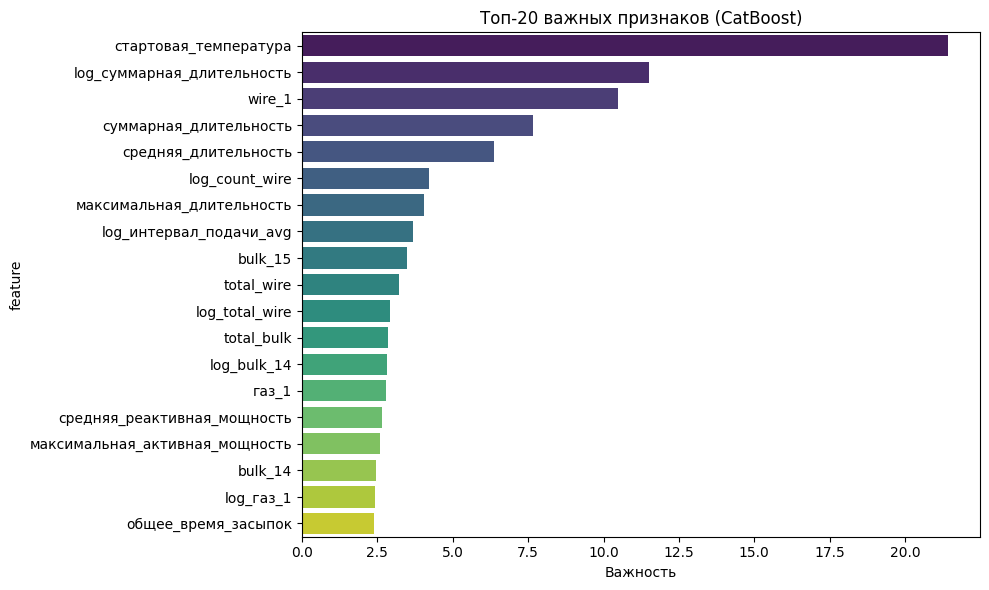

In [116]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_cb_final.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

logger.info("Топ-20 важных признаков:")
logger.info("\n" + feature_importance.head(20).to_string(index=False))

plt.figure(figsize=(10, max(6, len(feature_importance.head(20))*0.3)))
sns.barplot(data=feature_importance.head(20), y='feature', x='importance', palette='viridis')
plt.title('Топ-20 важных признаков (CatBoost)')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

Таргет зависит от стартовой температуры, поэтому необходимо больше уделать этому внимания  
Плюс важную роль играет и продолжительность процесса

### связь с таргетом

2026-03-05 10:54:35 [INFO] __main__: Исследуем зависимость целевой переменной от признака: стартовая_температура


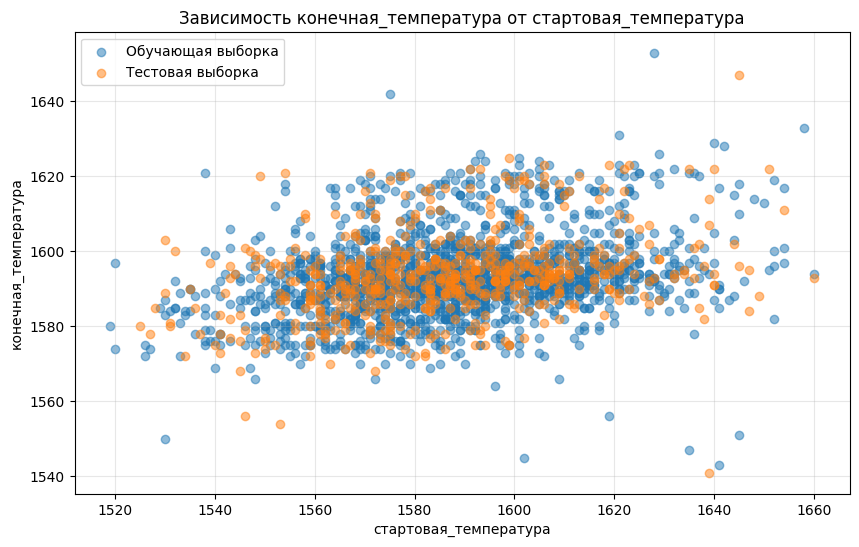

In [117]:
top_feature = feature_importance.iloc[0]['feature']
logger.info(f"Исследуем зависимость целевой переменной от признака: {top_feature}")


plt.figure(figsize=(10, 6))
plt.scatter(X_train[top_feature], y_train, alpha=0.5, label='Обучающая выборка')
plt.scatter(X_test[top_feature], y_test, alpha=0.5, label='Тестовая выборка')
plt.xlabel(top_feature)
plt.ylabel(TARGET)
plt.title(f'Зависимость {TARGET} от {top_feature}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

График показывает прямую зависимость конечной температуры от стартовой:  
- чем выше старт, тем выше финиш (логично для нагрева).  

Разброс при одинаковом старте говорит о влиянии других факторов (мощность, длительность и пр.).  
Обучающая и тестовая выборки лежат в одной области — распределения согласованы, модель сможет обобщать.

### дополнительный анализ

2026-03-05 10:54:36 [INFO] __main__: Среднее значение конечная_температура по группам признака стартовая_температура:
2026-03-05 10:54:36 [INFO] __main__: 
             group        mean  count
(1518.999, 1568.0] 1588.245810    358
  (1568.0, 1581.0] 1592.209497    358
  (1581.0, 1593.0] 1593.515670    351
  (1593.0, 1608.0] 1595.551622    339
  (1608.0, 1660.0] 1597.482353    340


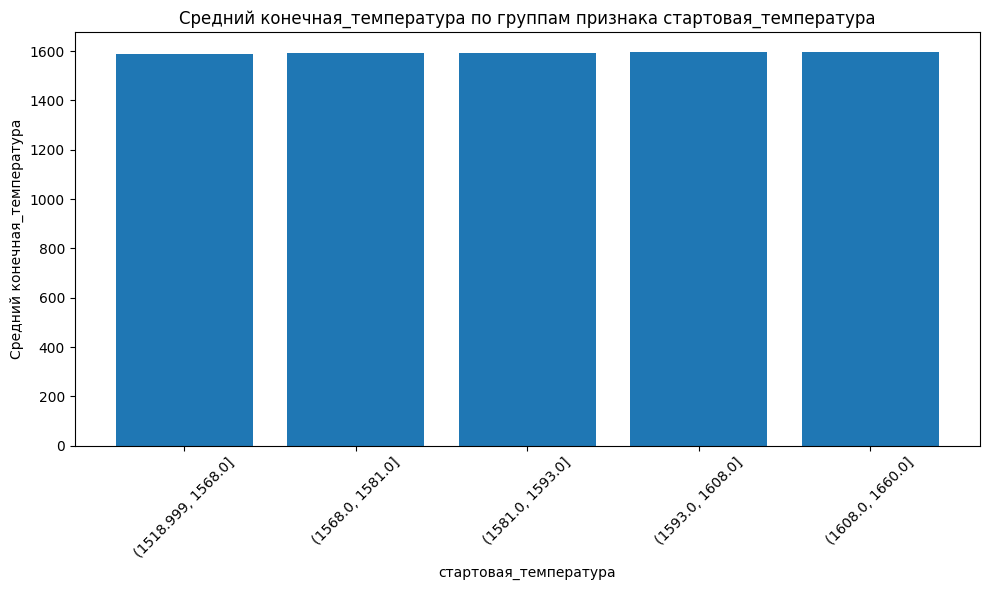

In [118]:
df_temp = X_train[[top_feature]].copy()
df_temp[TARGET] = y_train

df_temp['group'] = pd.qcut(df_temp[top_feature], q=5, duplicates='drop')
group_stats = df_temp.groupby('group')[TARGET].agg(['mean', 'count']).reset_index()

logger.info(f"Среднее значение {TARGET} по группам признака {top_feature}:")
logger.info("\n" + group_stats.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.bar(range(len(group_stats)), group_stats['mean'], tick_label=group_stats['group'].astype(str))
plt.xlabel(top_feature)
plt.ylabel(f'Средний {TARGET}')
plt.title(f'Средний {TARGET} по группам признака {top_feature}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


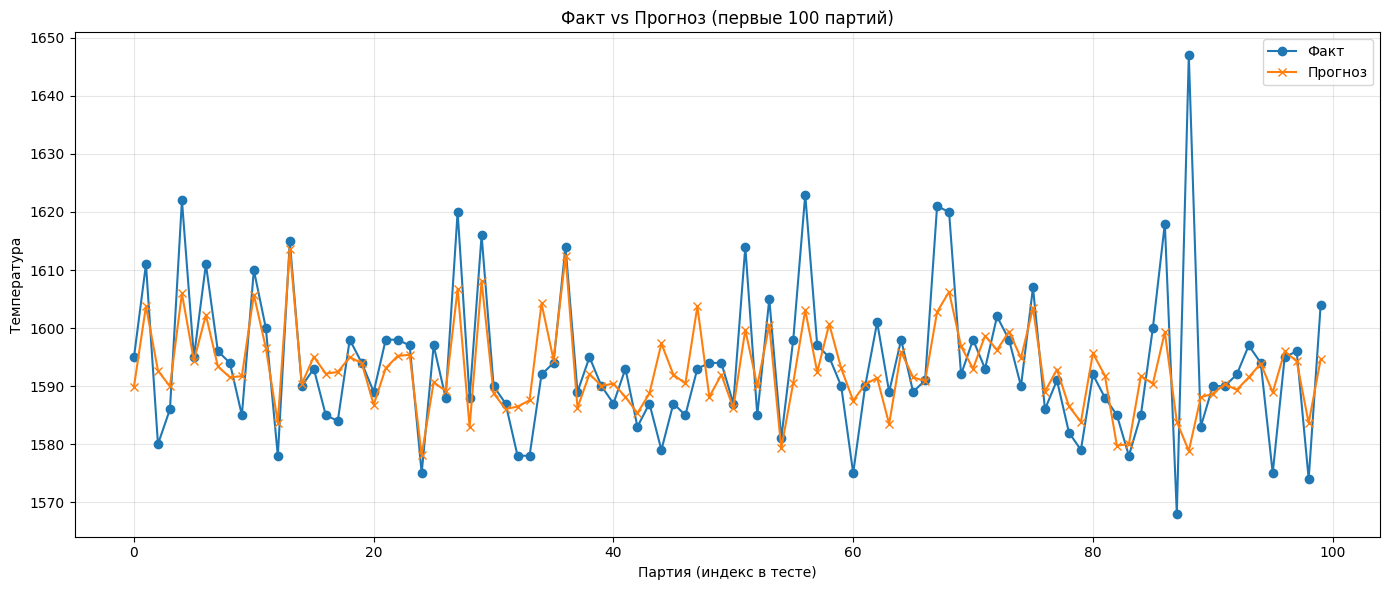

In [119]:
n = 100
y_true_100 = y_test.iloc[:n].values
y_pred_100 = y_test_pred_cb[:n]

plt.figure(figsize=(14, 6))
plt.plot(y_true_100, label='Факт', marker='o')
plt.plot(y_pred_100, label='Прогноз', marker='x')
plt.title('Факт vs Прогноз (первые 100 партий)')
plt.xlabel('Партия (индекс в тесте)')
plt.ylabel('Температура')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

В целом модель работает неплохо, но плохо себя чувствует в пиковых точках

# Выводы

1. Анализ исходных данных:  
Изучены таблицы из БД с префиксом data_: arc, bulk, bulk_time, gas, temp, wire, wire_time.  

Выявлены особенности:
- data_arc: нет пропусков, скорректированы временные метки, созданы новые признаки (длительность нагрева, полная мощность, соотношение мощностей, количество нагревов). Выполнено преобразование в широкий формат с агрегацией средних показателей.  
- data_bulk: пропуски заменены на 0 (отсутствие подачи), удалены признаки с долей пропусков, оставлены только используемые бункеры.  
- data_bulk_time: пропуски оставлены как NaT, рассчитаны общее время засыпок и средний интервал между подачами.  
- data_gas: данных мало, но они учтены.  
- data_temp: целевая переменная – последняя температура партии; отобраны ключи с минимум двумя замерами, температура ниже 1500 признана аномалией и удалена.  
- data_wire: аналогично bulk, пропуски = 0.  
- data_wire_time: рассчитаны общее время и средний интервал подачи проволоки.  

2. Обработка данных и создание признаков:  
Проведено объединение всех таблиц по ключу key, удалены временные столбцы.  
Выполнена оценка асимметрии (skewness) и логарифмирование сильно скошенных признаков (log-трансформация) для улучшения работы моделей.  
Проведён анализ мультиколлинеарности (VIF) – удалены признаки с VIF >10, что особенно важно для линейных моделей; для деревьев это не критично, но очистка выполнена.  
Итоговый датасет содержит 2329 записей, 53 колонки (после обработки).  

3. Построение моделей:  
Использованы: RandomForest, CatBoost, LightGBM, нейросеть PyTorch, константная модель (baseline).  
Оценка проводилась по MAE и R² на кросс-валидации (5 фолдов) и на тестовой выборке.  

Лучшие результаты показал CatBoost:  
- train MAE = 4.26, CV MAE = 6.19 (после оптимизации).  
- train R² = 0.65, CV R² = 0.41.  

LightGBM показал близкие значения (CV MAE 6.41), RandomForest – чуть хуже.  
Нейросеть дала значительно хуже результаты (MAE 8.06 на кросс-валидации).  
Константная модель (среднее значение) дала MAE 8.08 – ориентир для сравнения.  

4. Оптимизация гиперпараметров CatBoost:  
Применена Optuna с 50 trial'ами, 5-фолдной кросс-валидацией, ранней остановкой.  
Лучшие параметры: iterations=1500, depth=4, learning_rate=0.039, l2_leaf_reg=0.0057.  
После оптимизации качество улучшилось:  
- 3.89 против 4.26 на трейне  
- 6.30 на тесте против 6.19 при кроссвалидации на трейне  
т.е. надо повысить число триалов, иначе в подборе нет смысл  

5. Анализ важности признаков:  
Наиболее значимый признак – стартовая температура.  
Далее следуют:  
- суммарная_длительность,  
- log_суммарная_длительность,  
- wire_1 (6.3%),  
- максимальная_длительность, средняя_длительность, log_интервал_подачи_avg и другие.  

Зависимость конечной температуры от стартовой линейная, но присутствует разброс, обусловленный другими факторами.  

6. Графический анализ:  
Построен график зависимости конечной температуры от стартовой: подтверждена положительная корреляция, распределения train/test совпадают, модель способна обобщать.  
Дополнительно исследована группировка по квантилям стартовой температуры: средняя конечная температура монотонно растёт, но разброс указывает на влияние иных параметров.  

7. Выводы по качеству модели:  
Модель CatBoost с оптимизированными параметрами даёт приемлемую точность прогноза конечной температуры (MAE ≈ 6.3 C при среднем значении около 1600 C).  
Ошибка несколько выше в пиковых значениях (крайних температурах), что характерно для регрессионных моделей.  
R² = 0.4 на тесте означает, что модель объясняет 40% дисперсии целевой переменной – умеренный результат, но для производственных задач может быть достаточным.  

8. Рекомендации по обучению:  
Для дальнейшего улучшения качества можно:  
- Увеличить число испытаний Optuna (до 50–100) с суженными диапазонами параметров.  
- Попробовать ансамблирование лучших моделей (CatBoost + LightGBM).  
- Провести более тщательный feature engineering: добавить взаимодействия признаков, агрегаты по временным окнам.  
- Рассмотреть использование градиентного бустинга с другими функциями потерь (Huber, Quantile) для учёта хвостов распределения.  
- Нормализовать целевую переменную для нейросетей и подобрать архитектуру (больше данных, меньше слоёв, dropout).  

9. Рекомендации по производству:
- Для оперативного контроля качества плавки можно внедрить модель, прогнозирующую конечную температуру на основе стартовой температуры, длительности нагрева и объёмов добавок.  
- Особое внимание следует уделять контролю стартовой температуры – её влияние максимально.  
- Рекомендуется вести учёт интервалов подачи материалов и их объёмов, так как они значимо влияют на результат.  
- При отклонении прогноза от фактической температуры более чем на 10–12 C стоит анализировать технологический режим (возможны сбои в подаче, нештатные ситуации).  